# Extended Perturbation Analysis — scHopfield Hematopoiesis

Extends the lineage driver analysis from `notebooks/06_lineage_drivers.ipynb` with five additional experiments:

| Section | Analysis | Priority | Est. Runtime |
|---------|----------|----------|--------------|
| A | Stat3 OE flow (bidirectionality check) | Medium | ~5 min |
| B | Time-resolved ΔX heatmaps (10 ODE runs) | Medium | ~30 min |
| C | ODE phase portraits (Gata1 vs Stat3 plane) | Medium | ~5 min |
| D | Dose-response curves (20 ODE runs) | High | ~60 min |
| E | Bootstrap stability (100 × score_driver_tfs) | High | ~15 min |

**Out of scope here:**
- Perturb-seq correlation (requires external dataset download)
- Regularization robustness (requires model retraining ~3×30–60 min)

Loads from checkpoints at `/Users/bernaljp/Documents/SCHData/checkpoints/06_lineage_drivers/` — no retraining needed.


## Package vs Notebook: Methods Classification

Which analytical methods in this notebook are **generic enough to move into the `scHopfield` package** vs **study-specific and should remain here**.

---

### MOVE TO PACKAGE (`sch`)

| Cell / Section | Method | Suggested API |
|----------------|--------|---------------|
| §A — Stat3 KO flow (cells 34-35) | Per-cell inner product between KO perturbation flow and WT Hopfield velocity; grid interpolation for embedding arrows | `sch.tl.compute_perturbation_alignment(adata, ko_adata, wt_flow_key)` |
| §D — Dose-response (cells 16-18) | Multi-level ODE sweep (0 to 2× natural expression), lineage bias at each level | `sch.dyn.run_dose_response(adata, genes, levels, simulate_kwargs)` |
| §G — Tier classification (cell 23) | Mann-Whitney U differential expression between two arbitrary cluster groups; returns ranked gene table | `sch.tl.lineage_de(adata, lineage_A_clusters, lineage_B_clusters)` |
| §H — W^c weight extraction (cell 26) | Per-gene combined regulatory weight `w_combined = W^c[anchor,:] + W^c[:,anchor]` across a set of cluster matrices | `sch.tl.grn_partner_weights(adata, anchor_gene, cluster_keys)` |

---

### KEEP IN NOTEBOOK (study-specific)

| Cell / Section | Method | Why notebook-only |
|----------------|--------|-------------------|
| §H — 4+4+4+4 selection (cell 26) | Multi-criterion sequential partner selection: hit-count + ery-top + mye-top + all-cluster, 4 genes each | Selection thresholds (K=10, N=4, MIN_HITS) and the recipe framing are paper choices |
| §H — Recipe sweep + plot (cells 27-28) | Anchored double-KO sweep, direction-corrected synergy score, per-criterion border-color plot | Anchor choices (Gata1/Stat3), plot design, and interpretation are paper-specific |
| §I — STAT family circuit (cell 30) | W^c sub-matrix for STAT TFs; concordance table vs literature | Biological question (STAT family in hematopoiesis) is not generalisable |
| §B — Cascade timing (cells 37-38) | Log-scale time series of cluster-mean |ΔX| for Gata1/Stat3 KO | Specific time range, gene choices, cluster palette are study-specific |
| §C/§D — TF ranking + cluster heatmap (cells 40-42) | Lineage-bias bar chart and cluster |ΔX| heatmap | Specific to 16-candidate set and Paul 2015 cluster structure |
| Bootstrap stability (cells 19-21) | Gene-level bootstrap of lineage bias across resamplings | Specific to this candidate validation; generalised bootstrap wrapper could go to package later |


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
from pathlib import Path
from tqdm.auto import tqdm

import scanpy as sc
import scvelo as scv
import celloracle as co
import torch

import scHopfield as sch
from scHopfield.dynamics.simulation import simulate_shift_ode, simulate_perturbation_ode
from scHopfield._utils.io import get_genes_used, get_matrix, to_numpy

sc.settings.verbosity = 1
scv.settings.verbosity = 1

print(f"scHopfield: {sch.__version__}")
print(f"torch: {torch.__version__}")

scHopfield: 0.1.0
torch: 2.7.0


In [ ]:
# ── Constants (mirror nb06 exactly) ──────────────────────────────────────────
CLUSTER_KEY   = 'paul15_clusters'
SPLICED_KEY   = 'Ms'
BASIS         = 'draw_graph_fa'
VELOCITY_KEY  = 'velocity_S'
VELOCITY_SCALE = 500.0

DEVICE = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available()
          else 'cpu')

ERYTHROID = ['1Ery','2Ery','3Ery','4Ery','5Ery','6Ery','7MEP','8Mk']
MYELOID   = ['9GMP','10GMP','11DC','12Baso','13Baso','14Mo','15Mo','16Neu','17Neu','18Eos','19Lymph']
CLUSTER_ORDER = ['1Ery','2Ery','3Ery','4Ery','5Ery','6Ery','7MEP','8Mk',
                 '9GMP','10GMP','11DC','12Baso','13Baso','14Mo','15Mo',
                 '16Neu','17Neu','18Eos','19Lymph']

# ── Checkpoint paths ──────────────────────────────────────────────────────────
SAVE_DIR     = Path('/Users/bernaljp/Documents/SCHData/checkpoints/06_lineage_drivers')
MODEL_PATH   = str(SAVE_DIR / 'model.h5sch')
EXT_SAVE_DIR = Path('/Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended')
EXT_SAVE_DIR.mkdir(parents=True, exist_ok=True)

_WT_VEL_FLOW_KEY = f'original_velocity_flow_{BASIS}'

print(f"Device : {DEVICE}")
print(f"SAVE_DIR exists : {SAVE_DIR.exists()}")
print(f"MODEL_PATH exists: {Path(MODEL_PATH).exists()}")
print(f"EXT_SAVE_DIR : {EXT_SAVE_DIR}")

Device : mps
SAVE_DIR exists : True
MODEL_PATH exists: True
EXT_SAVE_DIR : /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended


In [27]:
# ── Load data + model (same as nb06 resume path, ~3-5 min) ───────────────────
oracle_demo = co.data.load_tutorial_oracle_object()
adata = oracle_demo.adata.copy()
adata.var['scHopfield_used'] = True

# Create synthetic spliced/unspliced so scv.pp.moments can compute Ms
adata.layers['spliced']   = adata.layers['normalized_count']
adata.layers['unspliced'] = adata.layers['normalized_count']
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
_ = adata.layers.pop('unspliced')

sch.pp.estimate_velocity_from_pseudotime(
    adata, pseudotime_key='Pseudotime',
    spliced_key=SPLICED_KEY, connectivity_key='connectivities',
    scale=VELOCITY_SCALE, store_key=VELOCITY_KEY
)
scv.tl.velocity_graph(adata, vkey=VELOCITY_KEY, xkey=SPLICED_KEY, n_jobs=-1)
scv.tl.velocity_embedding(adata, basis=BASIS, vkey=VELOCITY_KEY)
adata.obsm[f'velocity_{BASIS}'] = adata.obsm[f'{VELOCITY_KEY}_{BASIS}']

# Degradation rates (gamma = clip(|v| / |x|), same formula as nb06)
expression = adata.layers[SPLICED_KEY].copy()
velocities = adata.layers[VELOCITY_KEY]
mean_expr  = np.abs(expression).mean(axis=0) + 1e-6
mean_vel   = np.abs(velocities).mean(axis=0)
gamma      = np.clip(mean_vel / mean_expr, 0.1, 10.0)
adata.var['gamma'] = gamma
print(f"Gamma range: [{gamma.min():.3f}, {gamma.max():.3f}]")

result = sch.tl.load_model(adata, MODEL_PATH, overwrite=True)
if result is not None:
    adata = result

sch.tl.compute_energies(adata, cluster_key=CLUSTER_KEY, spliced_key=SPLICED_KEY)
sch.tl.compute_network_centrality(adata, cluster_key=CLUSTER_KEY, threshold_number=40000)
sch.tl.energy_gene_correlation(adata, spliced_key=SPLICED_KEY, cluster_key=CLUSTER_KEY)

print(f"\nadata: {adata.shape}")
print(f"Clusters: {sorted(adata.obs[CLUSTER_KEY].unique())}")

  0%|          | 0/2671 [00:00<?, ?cells/s]

Gamma range: [0.100, 0.100]


Model loaded from '/Users/bernaljp/Documents/SCHData/checkpoints/06_lineage_drivers/model.h5sch'  |  clusters=['10GMP', '11DC', '12Baso', '13Baso', '14Mo', '15Mo', '16Neu', '17Neu', '18Eos', '19Lymph', '1Ery', '2Ery', '3Ery', '4Ery', '5Ery', '6Ery', '7MEP', '8Mk', '9GMP']  |  genes=1999



adata: (2671, 1999)
Clusters: ['10GMP', '11DC', '12Baso', '13Baso', '14Mo', '15Mo', '16Neu', '17Neu', '18Eos', '19Lymph', '1Ery', '2Ery', '3Ery', '4Ery', '5Ery', '6Ery', '7MEP', '8Mk', '9GMP']


In [90]:
# ── Load nb06 results + compute WT flow ──────────────────────────────────────
single_ko_bias        = pd.read_csv(SAVE_DIR / 'single_ko_bias.csv', index_col=0)
single_ko_per_cluster = pd.read_csv(SAVE_DIR / 'single_ko_per_cluster.csv', index_col=0)
with open(SAVE_DIR / 'candidates.json') as f:
    CANDIDATES = json.load(f)

print(f"Candidates ({len(CANDIDATES)}): {CANDIDATES}")
print(single_ko_bias[['lineage_bias']].sort_values('lineage_bias').to_string())

# WT Hopfield velocity flow in embedding (reference for all lineage bias computations)
sch.tl.calculate_flow(
    adata,
    source='original',
    basis=BASIS,
    method='hopfield',
    cluster_key=CLUSTER_KEY,
    store_key=_WT_VEL_FLOW_KEY,
    verbose=False,
)
print(f"\nWT flow → adata.obsm['{_WT_VEL_FLOW_KEY}']")

Candidates (16): ['Ybx1', 'Stat1', 'Nr3c1', 'Myc', 'Nfkb1', 'Rreb1', 'Zbtb7a', 'Zbtb1', 'Mef2c', 'Irf2', 'Nfatc3', 'Irf8', 'Stat3', 'Runx1', 'Rel', 'Irf1']
          lineage_bias
gene                  
E2f4         -0.274346
Gata1        -0.263741
Myc          -0.087577
Zbtb7a       -0.069413
Nr3c1        -0.049627
Stat5a       -0.046494
Brf1         -0.044020
Lmo2         -0.041961
Cxxc1        -0.040137
Nfia         -0.037328
Smarcc1      -0.032073
Smarcc2      -0.028193
Stat1        -0.026116
Zbtb1        -0.025452
Rreb1        -0.018722
Smarca5      -0.012709
Nfatc3       -0.011476
Irf2         -0.008313
Bptf         -0.007629
Elf1         -0.006823
Ezh2         -0.006806
Arhgef12     -0.006465
Nfkb1        -0.005623
Cbx5         -0.004378
Bcl11a       -0.004111
Nfya         -0.003611
Meis1        -0.001950
Cux1         -0.001619
Rel          -0.000754
Mef2c         0.001584
Foxp1         0.002243
Ybx1          0.002409
Runx2         0.003911
Herpud1       0.006014
Nfic          0.

In [91]:
# ── Compute OE levels (99th percentile × 2, matching nb06 convention) ────────
gata1_raw_idx = list(adata.var.index).index('Gata1')
stat3_raw_idx  = list(adata.var.index).index('Stat3')

gata1_oe_val = float(np.percentile(adata.layers[SPLICED_KEY][:, gata1_raw_idx], 99)) * 2
stat3_oe_val  = float(np.percentile(adata.layers[SPLICED_KEY][:, stat3_raw_idx], 99)) * 2

print(f"Gata1 OE level : {gata1_oe_val:.3f}")
print(f"Stat3 OE level : {stat3_oe_val:.3f}")
print(f"Stat3 KO bias  : +{single_ko_bias.loc['Stat3','lineage_bias']:.4f} (erythroid)")
print(f"Expect Stat3 OE: negative (myeloid-biasing)")

# ── Run Stat3 OE simulation (~2-5 min) ───────────────────────────────────────
print("\nRunning Stat3 OE simulation...")
adata_stat3_oe = simulate_shift_ode(
    adata.copy(),
    perturb_condition={'Stat3': stat3_oe_val},
    cluster_key=CLUSTER_KEY,
    dt=5.0, n_steps=100,
    use_cluster_specific_GRN=True,
    n_jobs=-1, device=DEVICE,
)
print("Done.")

Gata1 OE level : 1.813
Stat3 OE level : 1.204
Stat3 KO bias  : +0.1648 (erythroid)
Expect Stat3 OE: negative (myeloid-biasing)

Running Stat3 OE simulation...
Done.


In [92]:
# ── Compute flow + lineage bias for Stat3 OE ─────────────────────────────────
sch.tl.calculate_flow(
    adata_stat3_oe,
    source='delta', basis=BASIS, method='celloracle',
    cluster_key=CLUSTER_KEY,
    store_key=f'perturbation_flow_{BASIS}',
    verbose=False,
)
sch.tl.calculate_inner_product(
    adata_stat3_oe,
    flow_key_1=_WT_VEL_FLOW_KEY,
    flow_key_2=f'perturbation_flow_{BASIS}',
    store_key='ko_vs_wt_inner_product',
)

bias_stat3_oe = sch.tl.compute_lineage_bias(
    adata_stat3_oe, adata, ERYTHROID, MYELOID, BASIS, _WT_VEL_FLOW_KEY,
    cluster_key=CLUSTER_KEY,
)
print(f"Stat3 OE lineage_bias = {bias_stat3_oe['lineage_bias']:.4f}")
print(f"Stat3 KO lineage_bias = {single_ko_bias.loc['Stat3','lineage_bias']:.4f}")
print(f"Bidirectional: {'YES ✓' if bias_stat3_oe['lineage_bias'] < 0 else 'NO — unexpected'}")

Stat3 OE lineage_bias = -0.0128
Stat3 KO lineage_bias = 0.1648
Bidirectional: YES ✓


In [93]:
import matplotlib
matplotlib.rcParams._get = matplotlib.rcParams.get
%matplotlib inline

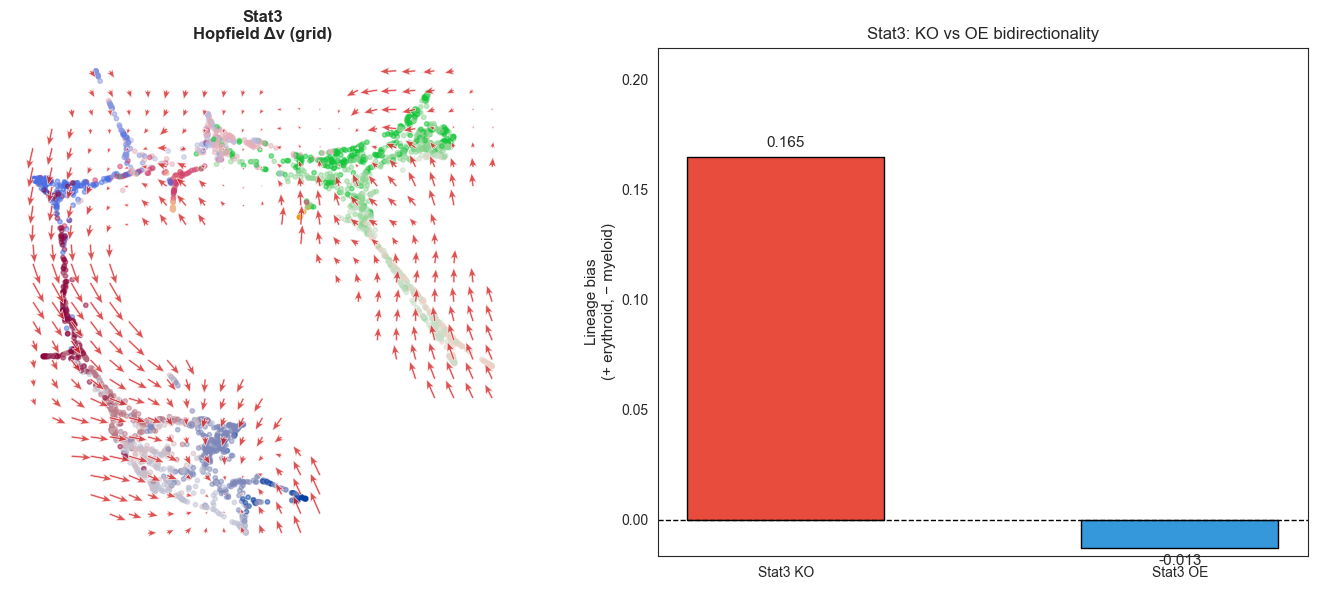

Saved → /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/stat3_oe_flow.png


In [95]:
import matplotlib.pyplot as plt
# ── Plot: Stat3 OE flow ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # Left: flow map (Stat3 KO)
# sch.pl.velocity_embedding_stream(
#     adata_stat3_ko,
#     vkey=f'perturbation_flow_{BASIS}',
#     basis=BASIS,
#     color=CLUSTER_KEY,
#     legend_loc='none',
#     title="Stat3 KO flow (CellOracle method)",
#     ax=axes[0],
# )

sch.tl.calculate_flow(
    adata_stat3_ko,
    source='delta',
    basis=BASIS,
    method='celloracle',
    cluster_key=CLUSTER_KEY,
    store_key=f'perturbation_flow_{BASIS}',
    verbose=False,
)

# Plot using the dynamic target_color
sch.pl.plot_flow(
    adata_stat3_ko,
    flow_key=f'perturbation_flow_{BASIS}',
    basis=BASIS,
    on_grid=True,
    ax=axes[0],
    n_grid=25,
    min_mass=10,
    scale=5,
    color='tab:red',
    cluster_key=CLUSTER_KEY,
    colors=colors,
    title=f'{gene}\nHopfield Δv (grid)',
)

# Right: bar chart comparing biases
genes_compare = ['Stat3 KO', 'Stat3 OE']
biases_compare = [single_ko_bias.loc['Stat3', 'lineage_bias'], bias_stat3_oe['lineage_bias']]
colors_compare = ['#E74C3C' if b > 0 else '#3498DB' for b in biases_compare]

bars = axes[1].bar(genes_compare, biases_compare, color=colors_compare, edgecolor='k', width=0.5)
axes[1].axhline(0, color='k', lw=1, ls='--')
axes[1].set_ylabel('Lineage bias\n(+ erythroid, − myeloid)', fontsize=11)
axes[1].set_title('Stat3: KO vs OE bidirectionality', fontsize=12)
for bar, val in zip(bars, biases_compare):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.003 * np.sign(val),
                 f'{val:.3f}', ha='center', va='bottom' if val > 0 else 'top', fontsize=11)
axes[1].set_ylim(min(biases_compare)*1.3, max(biases_compare)*1.3)

plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'stat3_oe_flow.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {EXT_SAVE_DIR / 'stat3_oe_flow.png'}")


In [32]:
# ── Run time-resolved simulations (checkpoint protected, ~30 min) ─────────────
timeseries_csv = EXT_SAVE_DIR / 'timeseries_cluster_effects.csv'
time_points = [20, 40, 60, 80, 100]

if timeseries_csv.exists():
    ts_df = pd.read_csv(timeseries_csv)
    print(f"Loaded from checkpoint: {len(ts_df)} rows")
else:
    # Store per-cell delta_X for each (gene, time_point)
    records = []
    for n_steps in tqdm(time_points, desc='Time points'):
        for gene, label in [('Gata1', 'Gata1_KO'), ('Stat3', 'Stat3_KO')]:
            adata_t = simulate_shift_ode(
                adata.copy(), {gene: 0.0},
                cluster_key=CLUSTER_KEY, dt=5.0, n_steps=n_steps,
                use_cluster_specific_GRN=True, n_jobs=-1, device=DEVICE,
            )
            # Compute mean |delta_X| per cluster per gene
            delta_X = adata_t.layers['delta_X']  # (n_cells, n_genes)
            genes_used = get_genes_used(adata_t)
            gene_names_used = list(adata_t.var.index[genes_used])

            for cluster in CLUSTER_ORDER:
                mask = adata_t.obs[CLUSTER_KEY] == cluster
                if mask.sum() == 0:
                    continue
                cluster_delta = np.abs(delta_X[mask][:, genes_used]).mean(axis=0)
                for gi, gname in enumerate(gene_names_used):
                    records.append({
                        'perturbation': label,
                        'n_steps': n_steps,
                        'cluster': cluster,
                        'gene': gname,
                        'mean_abs_delta': float(cluster_delta[gi]),
                    })

    ts_df = pd.DataFrame(records)
    ts_df.to_csv(timeseries_csv, index=False)
    print(f"Saved {len(ts_df)} rows → {timeseries_csv}")

print(ts_df.head())

Loaded from checkpoint: 379810 rows
  perturbation  n_steps cluster           gene  mean_abs_delta
0     Gata1_KO       20    1Ery  0610007L01Rik        0.820535
1     Gata1_KO       20    1Ery  0610010K14Rik        1.084797
2     Gata1_KO       20    1Ery  0910001L09Rik        1.038569
3     Gata1_KO       20    1Ery  1100001G20Rik        0.002025
4     Gata1_KO       20    1Ery  1110004E09Rik        0.293719


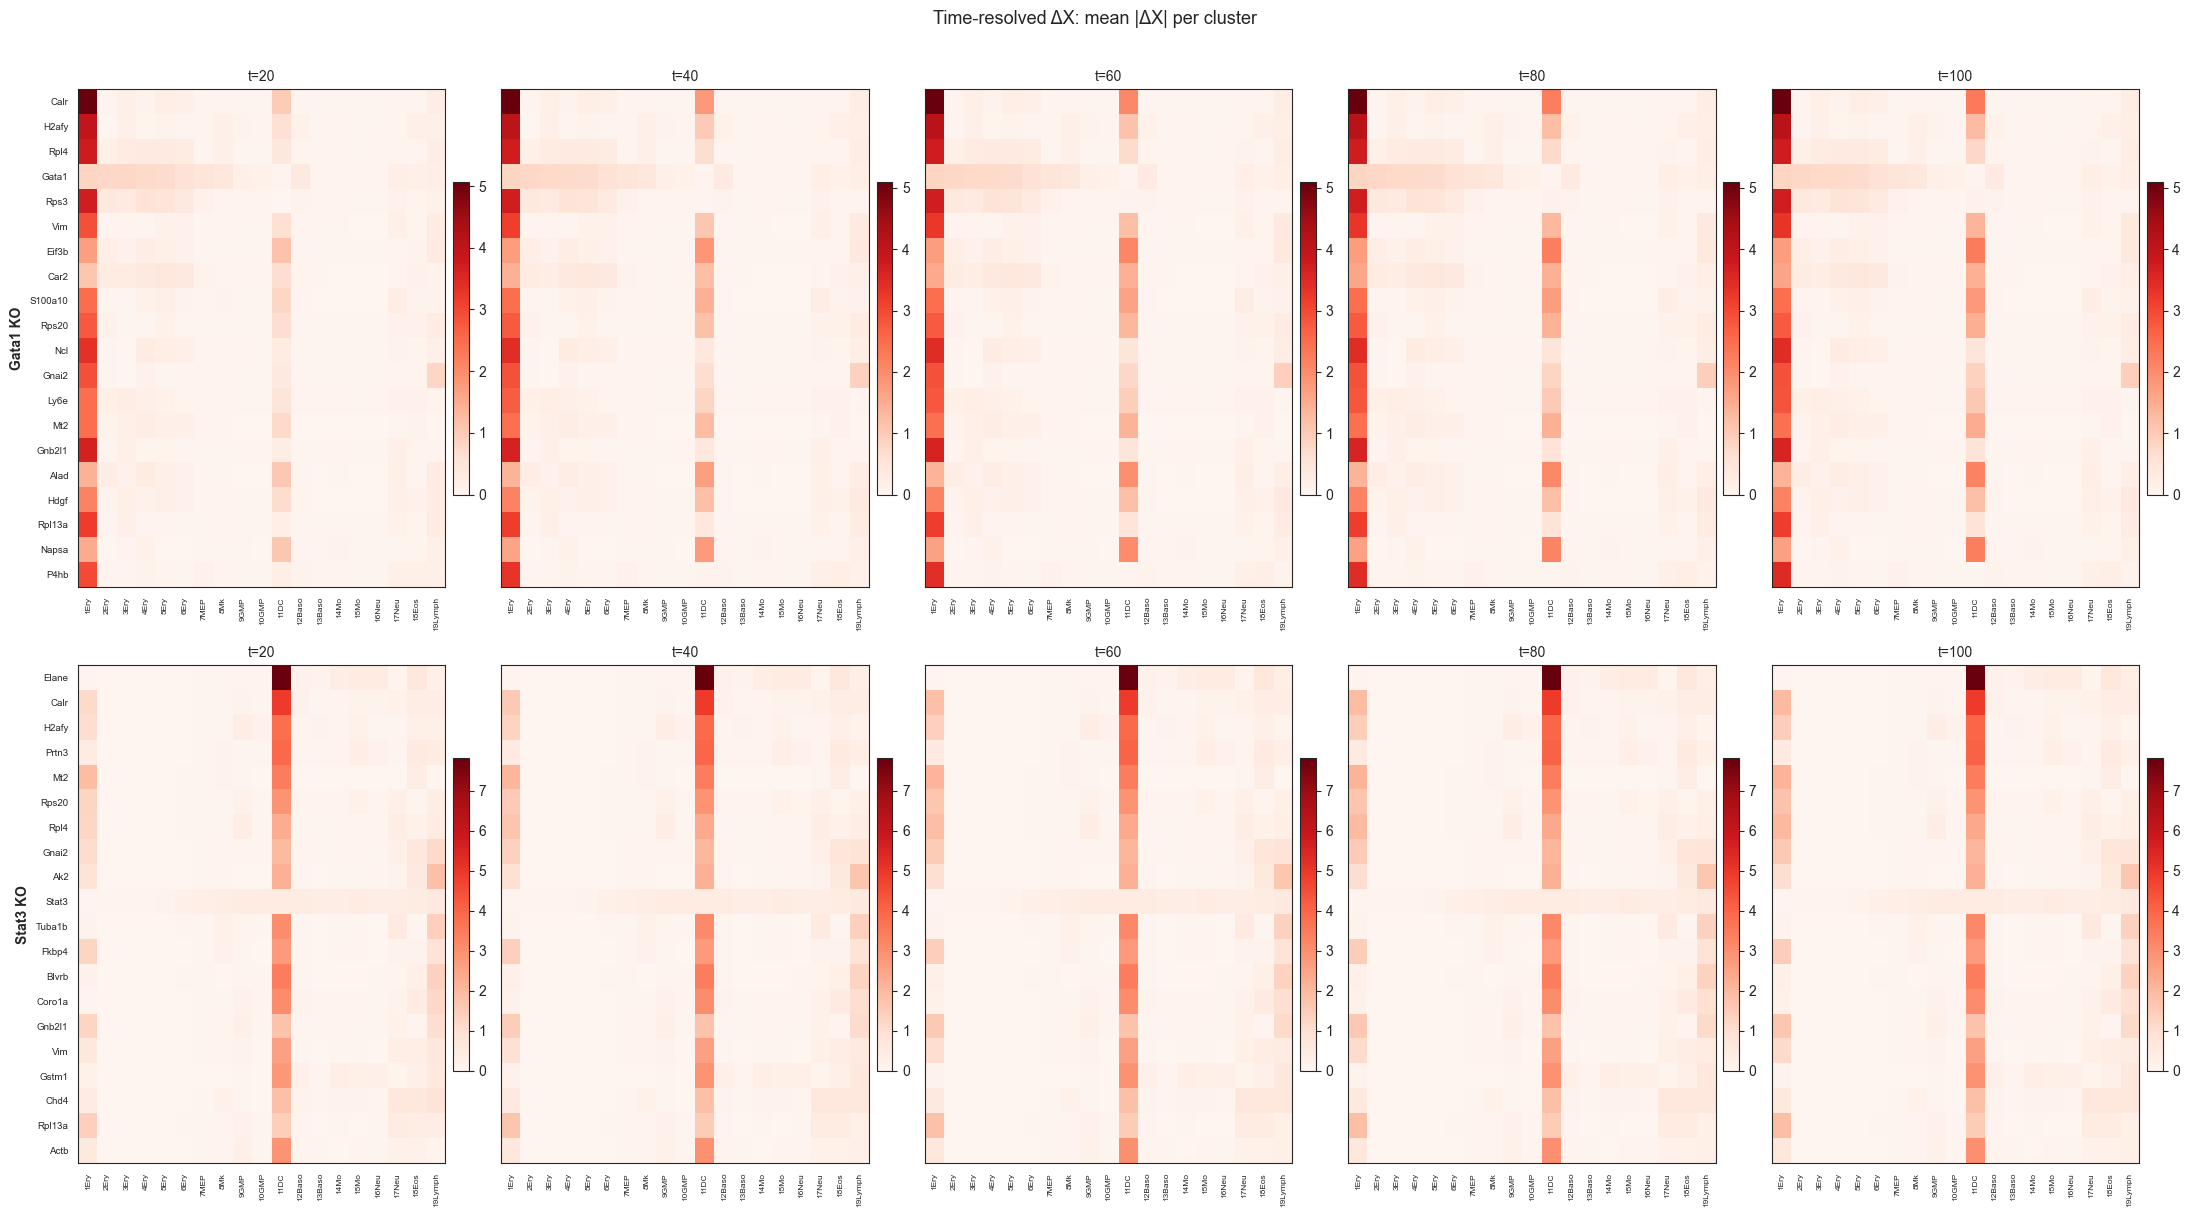

Saved → /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/timeseries_heatmaps.png


In [56]:
# ── Time-resolved heatmaps ────────────────────────────────────────────────────
N_TOP_GENES = 20

fig, axes = plt.subplots(2, 5, figsize=(22, 12))
fig.suptitle('Time-resolved ΔX: mean |ΔX| per cluster', fontsize=13, y=1.01)

for row_idx, pert in enumerate(['Gata1_KO', 'Stat3_KO']):
    sub = ts_df[ts_df['perturbation'] == pert]

    # Select top genes by mean |delta_X| across all clusters at t=100
    t100 = sub[sub['n_steps'] == 100].groupby('gene')['mean_abs_delta'].mean()
    top_genes = t100.nlargest(N_TOP_GENES).index.tolist()

    for col_idx, n_steps in enumerate(time_points):
        ax = axes[row_idx, col_idx]
        pivot = (sub[sub['n_steps'] == n_steps]
                 .pivot(index='gene', columns='cluster', values='mean_abs_delta')
                 .reindex(index=top_genes, columns=CLUSTER_ORDER)
                 .fillna(0))

        vmax = pivot.values.max()
        im = ax.imshow(pivot.values, aspect='auto', cmap='Reds', vmin=0, vmax=vmax)

        ax.set_title(f't={n_steps}', fontsize=10)
        ax.set_xticks(range(len(CLUSTER_ORDER)))
        ax.set_xticklabels(CLUSTER_ORDER, rotation=90, fontsize=6)

        if col_idx == 0:
            ax.set_yticks(range(N_TOP_GENES))
            ax.set_yticklabels(top_genes, fontsize=7)
            ax.set_ylabel(pert.replace('_', ' '), fontsize=10, fontweight='bold')
        else:
            ax.set_yticks([])

        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'timeseries_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {EXT_SAVE_DIR / 'timeseries_heatmaps.png'}")

In [78]:
# ── Phase portrait setup ──────────────────────────────────────────────────────
from scHopfield.dynamics.simulation import simulate_perturbation_ode

genes_used = get_genes_used(adata)
gene_names_used = list(adata.var.index[genes_used])

gata1_idx = gene_names_used.index('Gata1')
stat3_idx  = gene_names_used.index('Stat3')

t_span = np.linspace(0, 500, 100)  # 100 time points, t=0..500

# Pick 3 representative cells per cluster (first 3 of each)
representative_cells = {}
for cluster in ['1Ery', '2Ery', '3Ery']:
    mask = adata.obs[CLUSTER_KEY] == cluster
    representative_cells[cluster] = list(np.where(mask)[0][:3])
    print(f"{cluster}: cells {representative_cells[cluster]}")

conditions = {
    'WT':       {},
    'Gata1_KO': {'Gata1': 0.0},
    'Gata1_OE': {'Gata1': gata1_oe_val},
    'Stat3_KO': {'Stat3': 0.0},
    'Stat3_OE': {'Stat3': stat3_oe_val},
}

cond_colors = {
    'WT':       'gray',
    'Gata1_KO': '#E74C3C',
    'Gata1_OE': '#922B21',
    'Stat3_KO': '#2980B9',
    'Stat3_OE': '#1A5276',
}

1Ery: cells [35, 100, 294]
2Ery: cells [7, 9, 10]
3Ery: cells [2, 4, 8]


In [79]:
# ── Run trajectories (~5 min) ─────────────────────────────────────────────────
trajectories = {}  # (cluster, cond_name) → list of arrays (n_time, n_genes)

for cluster, cells in tqdm(representative_cells.items(), desc='Clusters'):
    for cond_name, perturbs in conditions.items():
        if perturbs:
            trajs = simulate_perturbation_ode(
                adata, cluster, cells, perturbs, t_span,
                spliced_key=SPLICED_KEY, n_jobs=-1, residual_gene_dynamics=True,
            )
        else:
            # WT: use simulate_perturbation_ode with empty perturbations
            trajs = simulate_perturbation_ode(
                adata, cluster, cells, {}, t_span,
                spliced_key=SPLICED_KEY, n_jobs=-1, residual_gene_dynamics=True,
            )
        trajectories[(cluster, cond_name)] = trajs  # list of (n_time, n_genes)

print(f"Trajectories computed: {len(trajectories)} (cluster, condition) pairs")

Clusters:   0%|          | 0/3 [00:00<?, ?it/s]

Trajectories computed: 15 (cluster, condition) pairs


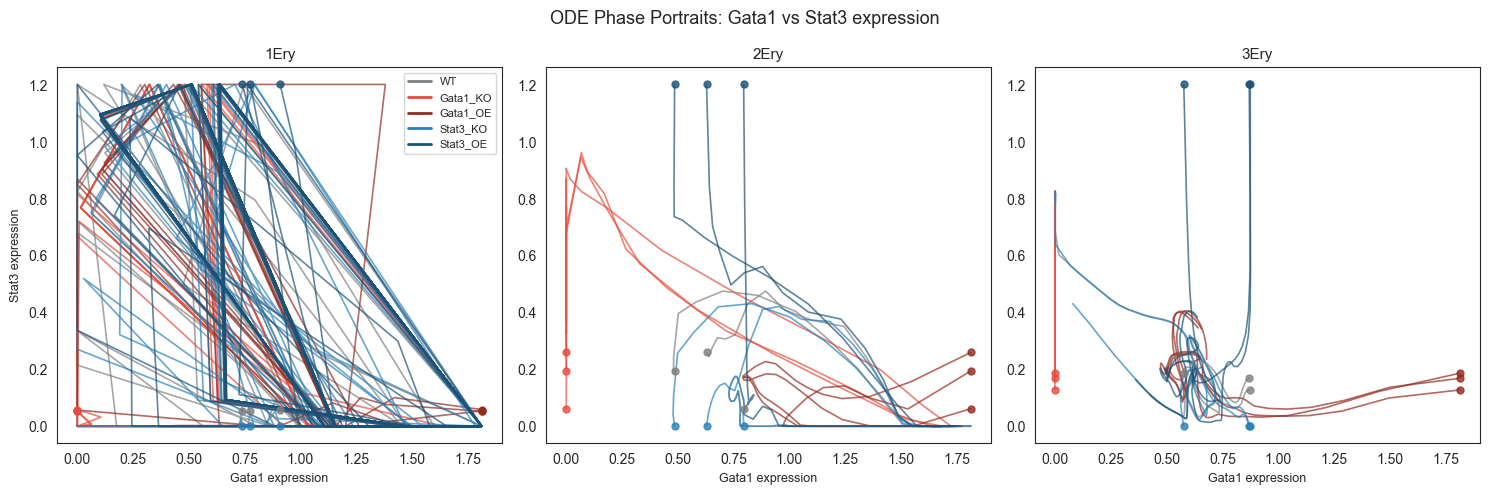

Saved → /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/phase_portraits.png


In [80]:
# ── Plot phase portraits ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ODE Phase Portraits: Gata1 vs Stat3 expression', fontsize=13)

for col_idx, cluster in enumerate(['1Ery', '2Ery', '3Ery']):
    ax = axes[col_idx]
    for cond_name, color in cond_colors.items():
        trajs = trajectories[(cluster, cond_name)]
        for traj in trajs:  # one line per representative cell
            traj_arr = np.array(traj)  # (n_time, n_genes_used)
            gata1_vals = traj_arr[:, gata1_idx]
            stat3_vals  = traj_arr[:, stat3_idx]
            ax.plot(gata1_vals, stat3_vals, color=color, alpha=0.7, lw=1.2,
                    label=cond_name if col_idx == 0 else '')
            # Mark start with a dot
            ax.scatter(gata1_vals[0], stat3_vals[0], color=color, s=25, zorder=5, alpha=0.8)

    ax.set_title(cluster, fontsize=11)
    ax.set_xlabel('Gata1 expression', fontsize=9)
    if col_idx == 0:
        ax.set_ylabel('Stat3 expression', fontsize=9)

# Single legend on first panel
handles = [plt.Line2D([0], [0], color=c, lw=2, label=n) for n, c in cond_colors.items()]
axes[0].legend(handles=handles, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'phase_portraits.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {EXT_SAVE_DIR / 'phase_portraits.png'}")

## Section D: Dose-Response Curves

20 ODE runs (Gata1 × 10 levels + Stat3 × 10 levels). Sweeps from 0 (KO) through natural expression to 2× max (strong OE). Reveals whether the erythroid/myeloid switch is threshold-like (sharp transition) or graded.

In [37]:
# ── Define dose levels ────────────────────────────────────────────────────────
n_levels = 10
gata1_max = float(np.percentile(adata.layers[SPLICED_KEY][:, gata1_raw_idx], 99))
stat3_max  = float(np.percentile(adata.layers[SPLICED_KEY][:, stat3_raw_idx], 99))

gata1_levels = np.linspace(0, gata1_max * 2, n_levels)
stat3_levels  = np.linspace(0, stat3_max  * 2, n_levels)

print(f"Gata1 natural max (99th pct): {gata1_max:.3f}")
print(f"Stat3  natural max (99th pct): {stat3_max:.3f}")
print(f"Gata1 levels: {np.round(gata1_levels, 3)}")
print(f"Stat3  levels: {np.round(stat3_levels, 3)}")

Gata1 natural max (99th pct): 0.907
Stat3  natural max (99th pct): 0.602
Gata1 levels: [0.    0.201 0.403 0.604 0.806 1.007 1.209 1.41  1.612 1.813]
Stat3  levels: [0.    0.134 0.268 0.401 0.535 0.669 0.803 0.937 1.07  1.204]


In [ ]:
# ── Run dose-response screen (checkpoint protected, ~40-60 min) ───────────────
dose_resp_csv = EXT_SAVE_DIR / 'dose_response.csv'

if dose_resp_csv.exists():
    dose_resp_df = pd.read_csv(dose_resp_csv)
    print(f"Loaded from checkpoint: {len(dose_resp_df)} rows")
else:
    df_gata1 = sch.dyn.run_dose_response(
        adata, 'Gata1', gata1_levels,
        lineage_A_clusters=ERYTHROID,
        lineage_B_clusters=MYELOID,
        basis=BASIS,
        wt_flow_key=_WT_VEL_FLOW_KEY,
        natural_max=gata1_max,
        cluster_key=CLUSTER_KEY,
        simulate_kwargs=dict(dt=5.0, n_steps=100,
                             use_cluster_specific_GRN=True,
                             n_jobs=-1, device=DEVICE),
    )
    df_stat3 = sch.dyn.run_dose_response(
        adata, 'Stat3', stat3_levels,
        lineage_A_clusters=ERYTHROID,
        lineage_B_clusters=MYELOID,
        basis=BASIS,
        wt_flow_key=_WT_VEL_FLOW_KEY,
        natural_max=stat3_max,
        cluster_key=CLUSTER_KEY,
        simulate_kwargs=dict(dt=5.0, n_steps=100,
                             use_cluster_specific_GRN=True,
                             n_jobs=-1, device=DEVICE),
    )
    dose_resp_df = pd.concat([df_gata1, df_stat3], ignore_index=True)
    dose_resp_df.to_csv(dose_resp_csv, index=False)
    print(f"Saved {len(dose_resp_df)} rows -> {dose_resp_csv}")

print(dose_resp_df)

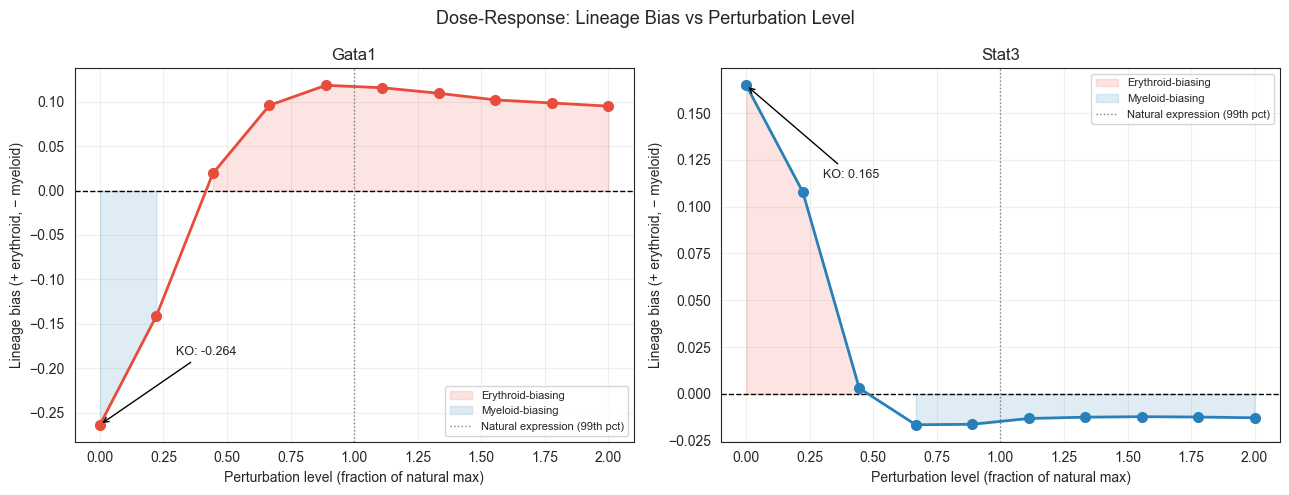

Saved → /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/dose_response.png


In [58]:
# ── Plot dose-response curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
fig.suptitle('Dose-Response: Lineage Bias vs Perturbation Level', fontsize=13)

gene_info = {
    'Gata1': {'color': '#E74C3C', 'ax': axes[0], 'max': gata1_max},
    'Stat3':  {'color': '#2980B9', 'ax': axes[1], 'max': stat3_max},
}

for gene, info in gene_info.items():
    sub = dose_resp_df[dose_resp_df['gene'] == gene].sort_values('level_frac')
    ax  = info['ax']

    ax.plot(sub['level_frac'], sub['lineage_bias'],
            'o-', color=info['color'], lw=2, ms=7, zorder=3)

    ax.fill_between(sub['level_frac'], sub['lineage_bias'], 0,
                    where=(sub['lineage_bias'] >= 0),
                    alpha=0.15, color='#E74C3C', label='Erythroid-biasing')
    ax.fill_between(sub['level_frac'], sub['lineage_bias'], 0,
                    where=(sub['lineage_bias'] < 0),
                    alpha=0.15, color='#2980B9', label='Myeloid-biasing')

    ax.axhline(0, color='k', lw=1, ls='--')
    ax.axvline(1.0, color='gray', lw=1, ls=':', label='Natural expression (99th pct)')

    ko_bias = sub[sub['level_frac'] < 0.01]['lineage_bias'].values[0]
    ax.annotate(f'KO: {ko_bias:.3f}',
                xy=(0, ko_bias), xytext=(0.3, ko_bias * 0.7),
                arrowprops=dict(arrowstyle='->', color='k', lw=1),
                fontsize=9)

    ax.set_xlabel('Perturbation level (fraction of natural max)', fontsize=10)
    ax.set_ylabel('Lineage bias (+ erythroid, − myeloid)', fontsize=10)
    ax.set_title(f'{gene}', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'dose_response.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {EXT_SAVE_DIR / 'dose_response.png'}")

Bootstrap rows for candidates: 1600
Unique candidates found: ['Irf1', 'Irf2', 'Irf8', 'Mef2c', 'Myc', 'Nfatc3', 'Nfkb1', 'Nr3c1', 'Rel', 'Rreb1', 'Runx1', 'Stat1', 'Stat3', 'Ybx1', 'Zbtb1', 'Zbtb7a']

Candidate bootstrap stats (lineage_bias = score_A - score_B, rank-based):
           mean        lo        hi
gene                               
Mef2c  -2182.06 -2472.050 -1813.300
Runx1  -1545.09 -1874.600 -1034.825
Irf2   -1400.41 -1823.000 -1037.950
Irf1   -1235.54 -1645.575  -592.150
Irf8   -1149.91 -1565.325  -767.950
Zbtb1   -502.07 -1009.150   107.625
Ybx1    -476.18  -633.675  -323.700
Stat3   -346.45  -794.050    65.675
Rel     -111.43  -763.675   438.775
Nfatc3    -7.20  -284.550   344.625
Rreb1    223.15  -268.250   764.475
Zbtb7a   499.95   163.650   844.725
Nfkb1    584.12   202.475   970.325
Myc      660.43   193.975  1104.525
Nr3c1    681.44   277.025  1163.300
Stat1   1708.23  1384.800  1950.675


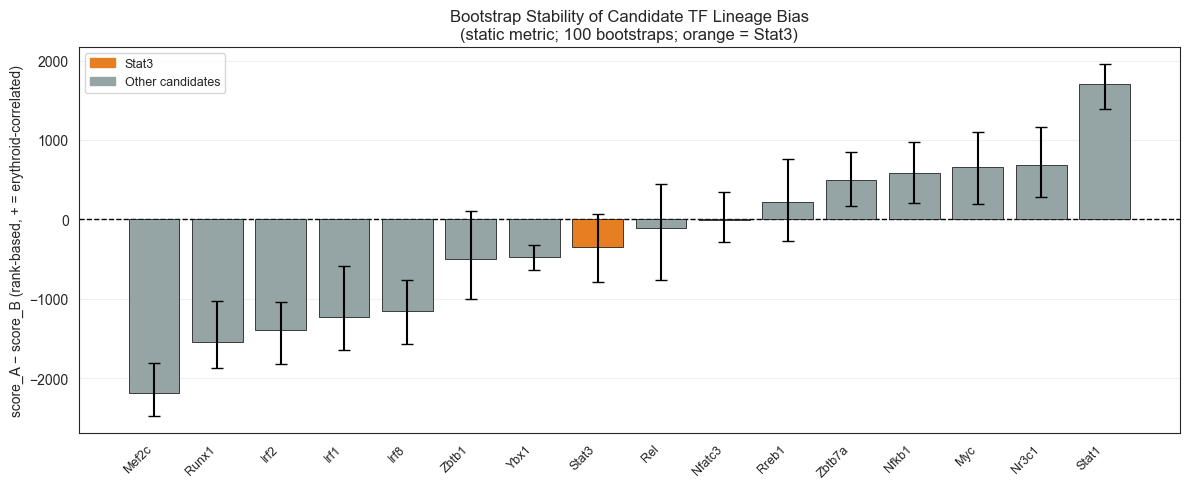

Saved → /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/bootstrap_stability.png

Stat3 bootstrap: mean=-346.4, 95% CI=[-794.0, 65.7]
CI excludes 0: No — CI spans 0


In [59]:
# ── Bootstrap stability plot (candidates only) ────────────────────────────────
# gene is the index in score_driver_tfs output — reset for groupby
boot_df2 = boot_df.reset_index()
boot_df2 = boot_df2.rename(columns={boot_df2.columns[0]: 'gene'})

# Filter to candidates only
boot_cand = boot_df2[boot_df2['gene'].isin(CANDIDATES)]
print(f"Bootstrap rows for candidates: {len(boot_cand)}")
print(f"Unique candidates found: {sorted(boot_cand['gene'].unique())}")

# Summarise: mean + 2.5th/97.5th percentile per gene
boot_stats = (boot_cand.groupby('gene')['lineage_bias']
              .agg(mean='mean',
                   lo=lambda x: np.percentile(x, 2.5),
                   hi=lambda x: np.percentile(x, 97.5))
              .sort_values('mean'))

print("\nCandidate bootstrap stats (lineage_bias = score_A - score_B, rank-based):")
print(boot_stats.to_string())

special_colors = {'Stat3': '#E67E22'}

fig, ax = plt.subplots(figsize=(12, 5))
for i, (gene, row) in enumerate(boot_stats.iterrows()):
    color = special_colors.get(gene, '#95A5A6')
    ax.bar(i, row['mean'], color=color, edgecolor='k', linewidth=0.5, zorder=3)
    ax.errorbar(i, row['mean'],
                yerr=[[row['mean'] - row['lo']], [row['hi'] - row['mean']]],
                fmt='none', color='black', capsize=4, lw=1.5, zorder=4)

ax.axhline(0, color='k', lw=1, ls='--')
ax.set_xticks(range(len(boot_stats)))
ax.set_xticklabels(boot_stats.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('score_A − score_B (rank-based, + = erythroid-correlated)', fontsize=10)
ax.set_title('Bootstrap Stability of Candidate TF Lineage Bias\n'
             '(static metric; 100 bootstraps; orange = Stat3)', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_handles = [Patch(color='#E67E22', label='Stat3'),
                  Patch(color='#95A5A6', label='Other candidates')]
ax.legend(handles=legend_handles, fontsize=9)

plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'bootstrap_stability.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {EXT_SAVE_DIR / 'bootstrap_stability.png'}")

# Stat3 stability summary
stat3_lo = boot_stats.loc['Stat3', 'lo']
stat3_hi = boot_stats.loc['Stat3', 'hi']
stat3_mean = boot_stats.loc['Stat3', 'mean']
print(f"\nStat3 bootstrap: mean={stat3_mean:.1f}, 95% CI=[{stat3_lo:.1f}, {stat3_hi:.1f}]")
print(f"CI excludes 0: {'YES ✓' if (stat3_lo > 0 or stat3_hi < 0) else 'No — CI spans 0'}")

In [40]:
# ── Bootstrap stability (checkpoint protected, ~10-20 min) ────────────────────
boot_csv = EXT_SAVE_DIR / 'bootstrap_stability.csv'

if boot_csv.exists():
    boot_df = pd.read_csv(boot_csv, index_col=0)
    print(f"Loaded from checkpoint: {len(boot_df)} rows")
else:
    n_bootstraps = 100
    boot_results = []
    rng = np.random.default_rng(42)

    for b in tqdm(range(n_bootstraps), desc='Bootstrap'):
        # Resample cells within each cluster (with replacement)
        boot_idx = []
        for cluster in CLUSTER_ORDER:
            mask = adata.obs[CLUSTER_KEY] == cluster
            idx = np.where(mask)[0]
            if len(idx) > 0:
                boot_idx.extend(rng.choice(idx, size=len(idx), replace=True))

        adata_b = adata[boot_idx].copy()

        # Recompute energy-gene correlation (W matrices unchanged — loaded from model)
        sch.tl.compute_energies(adata_b, cluster_key=CLUSTER_KEY, spliced_key=SPLICED_KEY)
        sch.tl.energy_gene_correlation(adata_b, spliced_key=SPLICED_KEY, cluster_key=CLUSTER_KEY)

        # Score TFs using all candidate genes
        scores_b = sch.tl.score_driver_tfs(adata_b, ERYTHROID, MYELOID,
                                            cluster_key=CLUSTER_KEY)
        scores_b['bootstrap'] = b
        boot_results.append(scores_b[['lineage_bias', 'score_A', 'score_B', 'bootstrap']])

    boot_df = pd.concat(boot_results)
    boot_df.to_csv(boot_csv)
    print(f"Saved {len(boot_df)} rows → {boot_csv}")

print(f"Bootstrap shape: {boot_df.shape}")

Loaded from checkpoint: 199900 rows
Bootstrap shape: (199900, 4)


In [ ]:
# ── Bootstrap stability plot ──────────────────────────────────────────────────
# Summarise: mean + 2.5th/97.5th percentile per gene
boot_stats = (boot_df.groupby(level=0)['lineage_bias']
              .agg(mean='mean',
                   lo=lambda x: np.percentile(x, 2.5),
                   hi=lambda x: np.percentile(x, 97.5))
              .sort_values('mean'))

# Highlight Stat3 (secondary Pareto rank) and Gata1 if present
special_colors = {'Stat3': '#E67E22', 'Gata1': '#E74C3C'}

fig, ax = plt.subplots(figsize=(12, 5))
for i, (gene, row) in enumerate(boot_stats.iterrows()):
    color = special_colors.get(gene, '#95A5A6')
    ax.bar(i, row['mean'], color=color, edgecolor='k', linewidth=0.5, zorder=3)
    ax.errorbar(i, row['mean'],
                yerr=[[row['mean'] - row['lo']], [row['hi'] - row['mean']]],
                fmt='none', color='black', capsize=4, lw=1.5, zorder=4)

ax.axhline(0, color='k', lw=1, ls='--')
ax.set_xticks(range(len(boot_stats)))
ax.set_xticklabels(boot_stats.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Lineage bias (mean ± 95% CI across 100 bootstraps)', fontsize=10)
ax.set_title('Bootstrap Stability of TF Lineage Bias Scores\n'
             '(orange = Stat3; bars = 2.5th–97.5th percentile)', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color='#E67E22', label='Stat3'),
                  Patch(color='#95A5A6', label='Other candidates')]
ax.legend(handles=legend_handles, fontsize=9)

plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'bootstrap_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {EXT_SAVE_DIR / 'bootstrap_stability.png'}")
print(f"\nStat3 95% CI: [{boot_stats.loc['Stat3','lo']:.4f}, {boot_stats.loc['Stat3','hi']:.4f}]")
# Check if 0 is within Stat3 CI
stat3_lo = boot_stats.loc['Stat3','lo']
stat3_hi = boot_stats.loc['Stat3','hi']
print(f"Stat3 rank robust: {'YES ✓ (CI excludes 0)' if stat3_lo > 0 else 'CI includes 0 — weaker evidence'}")

## Section G: Stat3 Tier Classification via Differential Expression

**Question:** Is Stat3 a Level 2 result (differential expression also finds it) or a Level 3 result (only the scHopfield ODE screen finds it)?

Both outcomes are scientifically valid. Level 2 means the perturbation screen agrees with a simpler expression-based test — validating the model's directionality without being its unique contribution. Level 3 means DE does not prominently identify Stat3, making the perturbation screen's directionality prediction a genuinely novel contribution.

**Method:** Mann-Whitney U test on spliced expression (`Ms` layer) between erythroid clusters (1Ery-7MEP) and myeloid clusters (9GMP-18Eos). Rank all genes by |log2FC|. Gata1 should appear as erythroid-high (negative FC) as a sanity check.

In [ ]:
# ── Stat3 Tier Classification: Differential Expression ───────────────────────
de_csv = EXT_SAVE_DIR / 'de_results.csv'

if de_csv.exists():
    de_results = pd.read_csv(de_csv, index_col=0)
    print(f"Loaded from checkpoint: {len(de_results)} genes")
else:
    de_results = sch.tl.lineage_de(
        adata,
        lineage_A_clusters=ERYTHROID,
        lineage_B_clusters=MYELOID,
        cluster_key=CLUSTER_KEY,
        spliced_key=SPLICED_KEY,
    )
    de_results.to_csv(de_csv)
    print(f"Saved {len(de_results)} genes -> {de_csv}")

# ── Tier classification ───────────────────────────────────────────────────────
stat3_rank   = int(de_results.loc['Stat3', 'rank'])
stat3_log2fc = float(de_results.loc['Stat3', 'log2fc'])
stat3_pval   = float(de_results.loc['Stat3', 'pval'])
gata1_rank   = int(de_results.loc['Gata1', 'rank'])
gata1_log2fc = float(de_results.loc['Gata1', 'log2fc'])

tier = "Level 2" if stat3_rank <= 20 else "Level 3"
print(f"\n=== Stat3 Tier Classification ===")
print(f"Stat3  | rank={stat3_rank:4d} | log2FC={stat3_log2fc:+.3f} | p={stat3_pval:.2e}  -->  {tier}")
print(f"Gata1  | rank={gata1_rank:4d} | log2FC={gata1_log2fc:+.3f} (sanity: expected erythroid-high = negative FC)")
print()
if tier == "Level 2":
    print("Interpretation: Stat3 is a Level 2 finding.")
    print("  DE independently identifies it as lineage-specific.")
    print("  The perturbation screen adds mechanistic directionality.")
else:
    print("Interpretation: Stat3 is a Level 3 finding.")
    print("  DE does not prominently identify Stat3.")
    print("  The perturbation screen's identification is a novel ODE-only contribution.")

# ── Plot: top 20 TFs by |log2FC| ─────────────────────────────────────────────
top20 = de_results.head(20).copy()

bar_colors = []
for gene in top20.index:
    if gene == 'Stat3':
        bar_colors.append('#E67E22')
    elif gene == 'Gata1':
        bar_colors.append('#E74C3C')
    else:
        bar_colors.append('#3498DB' if top20.loc[gene, 'log2fc'] > 0 else '#E74C3C')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top20)), top20['log2fc'].values, color=bar_colors, edgecolor='k', linewidth=0.5)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel('log2FC (myeloid / erythroid)', fontsize=11)
ax.set_title(
    f'Tier classification: Stat3 expression profile across lineages\n'
    f'Stat3 rank={stat3_rank} of {len(de_results)} genes  ({tier})',
    fontsize=11
)
ax.invert_yaxis()

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#E67E22', label=f'Stat3 (rank {stat3_rank})'),
    Patch(color='#E74C3C', label='Gata1 / erythroid-high'),
    Patch(color='#3498DB', label='Myeloid-high'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'de_tier_classification.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved -> {EXT_SAVE_DIR / 'de_tier_classification.png'}")

In [101]:
# ── Inspect existing pair KO data ────────────────────────────────────────────
pair_ko_csv = SAVE_DIR / 'pair_ko_bias.csv'
pair_df_existing = pd.read_csv(pair_ko_csv)
print("Columns:", pair_df_existing.columns.tolist())
print("Shape:", pair_df_existing.shape)
print()
gata1_existing = pair_df_existing[(pair_df_existing['geneA']=='Gata1') | (pair_df_existing['geneB']=='Gata1')]
stat3_existing  = pair_df_existing[(pair_df_existing['geneA']=='Stat3')  | (pair_df_existing['geneB']=='Stat3')]
print(f"Existing pairs with Gata1: {len(gata1_existing)}")
print(f"Existing pairs with Stat3:  {len(stat3_existing)}")
print()
print("All existing pairs:")
for _, r in pair_df_existing.iterrows():
    print(f"  {r['geneA']:10s} + {r['geneB']:10s}  lineage_bias={r['lineage_bias']:+.4f}")

Columns: ['geneA', 'geneB', 'score_A', 'score_B', 'lineage_bias']
Shape: (66, 5)

Existing pairs with Gata1: 11
Existing pairs with Stat3:  11

All existing pairs:
  Irf8       + Nfia        lineage_bias=+0.0325
  Irf8       + Arhgef12    lineage_bias=+0.0617
  Irf8       + Ezh2        lineage_bias=+0.0634
  Irf8       + E2f4        lineage_bias=-0.1982
  Irf8       + Gata1       lineage_bias=-0.1960
  Irf8       + Myc         lineage_bias=-0.0149
  Cebpa      + Nfia        lineage_bias=-0.0135
  Cebpa      + Arhgef12    lineage_bias=+0.0152
  Cebpa      + Ezh2        lineage_bias=+0.0156
  Cebpa      + E2f4        lineage_bias=-0.2471
  Cebpa      + Gata1       lineage_bias=-0.2455
  Cebpa      + Myc         lineage_bias=-0.0626
  Meis1      + Nfia        lineage_bias=-0.0375
  Meis1      + Arhgef12    lineage_bias=-0.0068
  Meis1      + Ezh2        lineage_bias=-0.0078
  Meis1      + E2f4        lineage_bias=-0.2740
  Meis1      + Gata1       lineage_bias=-0.2610
  Meis1      + Myc  

## Section H: Recipe Double KO — Anchored Partner Selection

**Anchors:** Gata1, Stat3. For each anchor, sweep all 16 CANDIDATES as potential partners.

**Three independent approaches to partner selection:**

1. **W^c network weights** — For each anchor, extract outgoing weights (what it regulates) and incoming weights (what regulates it) from the inferred GRN. Partners with the strongest positive or negative mean weights are mechanistically motivated candidates.

2. **ΔX cosine similarity (model-specific)** — Using per-cluster mean |ΔX| from the existing `single_ko_per_cluster.csv` checkpoint, compute cosine similarity between the anchor's cluster-effect profile and each partner's. Partners with low similarity perturb *different* clusters → likely complementary effects. Note: this uses unsigned magnitudes; signed gene-space cosine similarity would require re-running single KO ODE simulations.

3. **Literature (documented separately)** — Known TF interactions from literature cross-referenced against the candidate list.

**Metrics (matching `06_lineage_drivers.ipynb` conventions):**
- `cancellation_error = double_bias - (bias_A + bias_B)` — deviation from additive expectation
- `dominant_epistasis = max_magnitude(synergy_ery, synergy_mye)` — per-lineage epistasis, then max by absolute magnitude
- `relative_epistasis = cancellation_error / |bias_anchor|` — normalized for cross-anchor comparison

In [ ]:

# ── H1: W^c partner selection — diversified 4+4+4+4 strategy ───────────────────────
#
# For each anchor we select up to 16 W^c candidates using four independent criteria,
# each contributing 4 genes (excluding genes already selected in prior steps):
#
#   Step 1 — Hit count:     top 4 by stability in anchor's lineage-specific clusters
#   Step 2 — Erythroid top: top 4 by mean |w_combined| across ERY clusters only
#   Step 3 — Myeloid top:   top 4 by mean |w_combined| across MYE clusters only
#   Step 4 — All-cluster:   top 4 by mean |w_combined| across all 19 clusters
#
# Anchor pools are fully independent: Gata1 != Stat3 candidate lists.

varp_keys = sorted([k for k in adata.varp.keys() if k.startswith('W_')])

ERY_KEYS = ['W_1Ery','W_2Ery','W_3Ery','W_4Ery','W_5Ery','W_6Ery','W_7MEP','W_8Mk']
MYE_KEYS = [k for k in varp_keys if k not in ERY_KEYS]
ALL_KEYS  = varp_keys

anchor_lineage = {'Gata1': ERY_KEYS, 'Stat3': MYE_KEYS}
print(f"Erythroid clusters ({len(ERY_KEYS)}): {ERY_KEYS}")
print(f"Myeloid clusters  ({len(MYE_KEYS)}): {MYE_KEYS}")
print(f"Total clusters:    {len(ALL_KEYS)}")

K        = 10   # top-K genes per cluster for hit-count stability
N_SELECT =  4   # genes per criterion


def pick_top_n(series, n, exclude, min_val=0.0):
    """Top-n by series value, excluding genes in `exclude` and below min_val."""
    candidates = series[~series.index.isin(exclude)]
    candidates = candidates[candidates >= min_val]
    return list(candidates.nlargest(n).index)

wc_data         = {}   # {anchor: DataFrame of selected W^c partners}
anchor_partners = {}   # {anchor: ordered list of selected partner names}

for anchor in ['Gata1', 'Stat3']:
    lineage_keys = anchor_lineage[anchor]

    # ── W^c weights via package API ────────────────────────────────────────────
    df_all = sch.tl.grn_partner_weights(adata, anchor, cluster_keys=ALL_KEYS)
    df_ery = sch.tl.grn_partner_weights(adata, anchor, cluster_keys=ERY_KEYS)
    df_mye = sch.tl.grn_partner_weights(adata, anchor, cluster_keys=MYE_KEYS)
    df_lin = sch.tl.grn_partner_weights(adata, anchor, cluster_keys=lineage_keys)

    # ── Build unified DataFrame with aggregate scores ──────────────────────────
    df = df_all.copy()
    df['w_abs_ery']     = df_ery['w_abs_all']
    df['w_abs_mye']     = df_mye['w_abs_all']
    df['w_abs_lineage'] = df_lin['w_abs_all']

    # Hit count: how often each gene appears in top-K by |w_combined| per lineage cluster
    lin_short  = [k.replace('W_', '') for k in lineage_keys]
    lin_cols   = [f'w_{s}' for s in lin_short if f'w_{s}' in df_lin.columns]
    W_lin_vals = df_lin[lin_cols].values.T   # (n_lineage_clusters, n_genes_minus_anchor)
    hit_arr    = np.zeros(len(df), dtype=int)
    for row in W_lin_vals:
        top_idx = np.argsort(np.abs(row))[-K:]
        hit_arr[top_idx] += 1
    df['hit_count'] = hit_arr

    # ── Sequential 4+4+4+4 selection (study-specific) ─────────────────────────
    selected = []

    # Step 1: stability in lineage clusters (hit_count)
    sel_1 = pick_top_n(df['hit_count'],  N_SELECT, selected + [anchor], min_val=1)
    selected.extend(sel_1)

    # Step 2: erythroid cluster signal
    sel_2 = pick_top_n(df['w_abs_ery'],  N_SELECT, selected + [anchor], min_val=0.001)
    selected.extend(sel_2)

    # Step 3: myeloid cluster signal
    sel_3 = pick_top_n(df['w_abs_mye'],  N_SELECT, selected + [anchor], min_val=0.001)
    selected.extend(sel_3)

    # Step 4: all-cluster mean
    sel_4 = pick_top_n(df['w_abs_all'],  N_SELECT, selected + [anchor], min_val=0.001)
    selected.extend(sel_4)

    wc_data[anchor]         = df.loc[selected].copy()
    anchor_partners[anchor] = selected

    # Annotate selection criterion
    criterion_map = {}
    for g in sel_1: criterion_map[g] = 'hit_count'
    for g in sel_2: criterion_map[g] = 'ery_top'
    for g in sel_3: criterion_map[g] = 'mye_top'
    for g in sel_4: criterion_map[g] = 'all_W'
    wc_data[anchor]['criterion'] = wc_data[anchor].index.map(criterion_map)

    print(f"\n{'='*64}")
    print(f"Anchor: {anchor} (lineage: {'erythroid' if anchor == 'Gata1' else 'myeloid'})")
    print(f"  Step 1 hit_count  ({len(sel_1)}): {sel_1}")
    print(f"  Step 2 ery_top    ({len(sel_2)}): {sel_2}")
    print(f"  Step 3 mye_top    ({len(sel_3)}): {sel_3}")
    print(f"  Step 4 all_W      ({len(sel_4)}): {sel_4}")
    print(f"  Total: {len(selected)} W^c candidates")
    print()
    display_cols = ['criterion','hit_count','w_abs_ery','w_abs_mye','w_abs_all']
    print(wc_data[anchor][display_cols].round(4).to_string())

print(f"\n{'='*64}")
print(f"Gata1 partners ({len(anchor_partners['Gata1'])}): {anchor_partners['Gata1']}")
print(f"Stat3  partners ({len(anchor_partners['Stat3'])}): {anchor_partners['Stat3']}")
overlap = set(anchor_partners['Gata1']) & set(anchor_partners['Stat3'])
print(f"Overlap (swept independently for each anchor): {overlap if overlap else 'none'}")

# ── Cosine similarity from per-cluster |DeltaX| (for candidates already in checkpoint) ──
single_ko_pc = pd.read_csv(SAVE_DIR / 'single_ko_per_cluster.csv', index_col=0)

cos_sim_scores = {}
for anchor in ['Gata1', 'Stat3']:
    vec_a = single_ko_pc.loc[anchor].values.astype(float) \
            if anchor in single_ko_pc.index else None
    norm_a = (np.linalg.norm(vec_a) + 1e-10) if vec_a is not None else 1.0
    sims = {}
    for partner in anchor_partners[anchor]:
        if vec_a is None or partner not in single_ko_pc.index:
            sims[partner] = np.nan
        else:
            vec_p  = single_ko_pc.loc[partner].values.astype(float)
            norm_p = np.linalg.norm(vec_p) + 1e-10
            sims[partner] = float(np.dot(vec_a, vec_p) / (norm_a * norm_p))
    cos_sim_scores[anchor] = sims


In [117]:

# ── H2: Expanded recipe ODE sweep — anchor-specific diversified pools ────────────────
#
# Partner pools (from cell 25):
#   Gata1: CANDIDATES (minus Gata1) + 16 W^c candidates (minus any already in CANDIDATES)
#   Stat3: CANDIDATES (minus Stat3)  + 16 W^c candidates (minus any already in CANDIDATES)
#
# Steps:
#   A. Single KO checkpoint — run single KOs for any new genes not yet computed
#   B. Double KO checkpoint — run double KOs for new (anchor, partner) pairs
#   C. Build recipe_df with expanded pools + wc_criterion annotation

ANCHORS = ['Gata1', 'Stat3']

sweep_partners = {
    'Gata1': [g for g in CANDIDATES if g != 'Gata1'] +
             [g for g in anchor_partners['Gata1'] if g not in CANDIDATES and g != 'Gata1'],
    'Stat3': [g for g in CANDIDATES if g != 'Stat3'] +
             [g for g in anchor_partners['Stat3'] if g not in CANDIDATES and g != 'Stat3'],
}

print("Sweep partner counts:")
for a, ps in sweep_partners.items():
    wc_new = [p for p in ps if p not in CANDIDATES]
    print(f"  {a}: {len(ps)} total  ({len(CANDIDATES)-1} CANDIDATES + {len(wc_new)} W^c-only: {wc_new})")

all_new_genes = sorted({g for ps in sweep_partners.values() for g in ps if g not in CANDIDATES})
print(f"\nAll unique new genes (not in CANDIDATES): {all_new_genes}")

# ──────────────────────────────────────────────────────────────────────────────
# A. Single KO checkpoint
# ──────────────────────────────────────────────────────────────────────────────
sko_csv    = SAVE_DIR / 'single_ko_bias.csv'
sko_pc_csv = SAVE_DIR / 'single_ko_per_cluster.csv'

existing_sko    = pd.read_csv(sko_csv,    index_col=0)
existing_sko_pc = pd.read_csv(sko_pc_csv, index_col=0)

new_sko_genes = [g for g in all_new_genes if g not in existing_sko.index]
print(f"\nSingle KO: {len(existing_sko)} already cached, {len(new_sko_genes)} new")
for g in new_sko_genes:
    print(f"  {g}")

if new_sko_genes:
    print(f"\nRunning {len(new_sko_genes)} new single KO simulations...")
    new_bias, new_pc = sch.dyn.run_ko_screen(
        adata,
        genes=new_sko_genes,
        lineage_A_clusters=ERYTHROID,
        lineage_B_clusters=MYELOID,
        basis=BASIS,
        wt_flow_key=_WT_VEL_FLOW_KEY,
        cluster_key=CLUSTER_KEY,
        cluster_order=CLUSTER_ORDER,
        simulate_kwargs=dict(dt=5.0, n_steps=100,
                             use_cluster_specific_GRN=True,
                             n_jobs=-1, device=DEVICE),
        verbose=True,
    )
    new_sko_df    = pd.DataFrame(new_bias).T
    new_sko_pc_df = pd.DataFrame(new_pc).T
    new_sko_df.index.name    = 'gene'
    new_sko_pc_df.index.name = 'gene'

    existing_sko    = pd.concat([existing_sko,    new_sko_df])
    existing_sko_pc = pd.concat([existing_sko_pc, new_sko_pc_df])
    existing_sko.to_csv(sko_csv)
    existing_sko_pc.to_csv(sko_pc_csv)
    print(f"Saved updated single KO checkpoint: {len(existing_sko)} genes total")

single_ko_dict = existing_sko[['score_A', 'score_B', 'lineage_bias']].to_dict('index')

print("\nNew gene single KO biases:")
for g in all_new_genes:
    b = single_ko_dict.get(g, {}).get('lineage_bias', float('nan'))
    print(f"  {g}: {b:+.4f}")

# ──────────────────────────────────────────────────────────────────────────────
# B. Double KO checkpoint
# ──────────────────────────────────────────────────────────────────────────────
recipe_csv = EXT_SAVE_DIR / 'recipe_double_ko.csv'

# Lookup from original 45-pair screen
existing_pairs = {}
for _, row in pair_df_existing.iterrows():
    val = {'score_A': row['score_A'], 'score_B': row['score_B'],
           'lineage_bias': row['lineage_bias']}
    existing_pairs[(row['geneA'], row['geneB'])] = val
    existing_pairs[(row['geneB'], row['geneA'])] = val

# Load previously computed recipe results
recipe_lookup = {}
if recipe_csv.exists():
    prev = pd.read_csv(recipe_csv)
    for _, row in prev.iterrows():
        recipe_lookup[(row['anchor'], row['partner'])] = {
            'score_A': np.nan, 'score_B': np.nan,
            'lineage_bias': row['double_bias']
        }

for key, val in existing_pairs.items():
    if key not in recipe_lookup:
        recipe_lookup[key] = val

# Determine new pairs needed
new_pairs = []
for anchor in ANCHORS:
    for partner in sweep_partners[anchor]:
        key, key_r = (anchor, partner), (partner, anchor)
        if key not in recipe_lookup and key_r not in recipe_lookup:
            new_pairs.append(key)

print(f"\nDouble KO: {len(recipe_lookup)} pairs cached, {len(new_pairs)} new to run")
for p in new_pairs:
    print(f"  {p[0]} + {p[1]}")

if new_pairs:
    print(f"\nRunning {len(new_pairs)} new double KO simulations...")
    new_dko, _ = sch.dyn.run_pairwise_ko_screen(
        adata,
        pairs=new_pairs,
        lineage_A_clusters=ERYTHROID,
        lineage_B_clusters=MYELOID,
        basis=BASIS,
        wt_flow_key=_WT_VEL_FLOW_KEY,
        cluster_key=CLUSTER_KEY,
        cluster_order=CLUSTER_ORDER,
        simulate_kwargs=dict(dt=5.0, n_steps=100,
                             use_cluster_specific_GRN=True,
                             n_jobs=-1, device=DEVICE),
        verbose=True,
    )
    for (gA, gB), v in new_dko.items():
        recipe_lookup[(gA, gB)] = v
    print(f"Done. Total cached pairs: {len(recipe_lookup)}")

# ──────────────────────────────────────────────────────────────────────────────
# C. Build recipe_df with criterion annotation
# ──────────────────────────────────────────────────────────────────────────────
def max_magnitude(a, b):
    return a if abs(a) >= abs(b) else b

records = []
for anchor in ANCHORS:
    anc_data    = single_ko_dict.get(anchor, {})
    score_A_anc = anc_data.get('score_A', 0.0)
    score_B_anc = anc_data.get('score_B', 0.0)
    bias_anc    = anc_data.get('lineage_bias', 0.0)
    bias_sign   = 1 if bias_anc > 0 else -1

    for partner in sweep_partners[anchor]:
        par_data    = single_ko_dict.get(partner, {})
        score_A_par = par_data.get('score_A', 0.0)
        score_B_par = par_data.get('score_B', 0.0)
        bias_par    = par_data.get('lineage_bias', 0.0)

        key      = (anchor, partner)
        key_rev  = (partner, anchor)
        pd_data  = recipe_lookup.get(key, recipe_lookup.get(key_rev, {}))
        double_bias  = pd_data.get('lineage_bias', np.nan)
        score_A_pair = pd_data.get('score_A', np.nan)
        score_B_pair = pd_data.get('score_B', np.nan)

        ce  = double_bias - (bias_anc + bias_par)
        re  = (ce / abs(bias_anc)) if abs(bias_anc) > 1e-6 else np.nan
        syn_ery = score_A_pair - max(score_A_anc, score_A_par)
        syn_mye = score_B_pair - max(score_B_anc, score_B_par)
        dom_epi = max_magnitude(syn_ery, syn_mye)
        syn_score = ce * bias_sign   # direction-corrected: positive = synergistic

        wc_df       = wc_data.get(anchor)
        in_wc       = (wc_df is not None) and (partner in wc_df.index)
        criterion   = wc_df.loc[partner, 'criterion'] if in_wc else ''
        hit_count_v = int(wc_df.loc[partner, 'hit_count']) if in_wc else 0
        w_abs_v     = float(wc_df.loc[partner, 'w_abs_all']) if in_wc else np.nan
        cos_v       = cos_sim_scores.get(anchor, {}).get(partner, np.nan)

        records.append({
            'anchor':             anchor,
            'partner':            partner,
            'double_bias':        double_bias,
            'bias_anchor':        bias_anc,
            'bias_partner':       bias_par,
            'additive_expected':  bias_anc + bias_par,
            'cancellation_error': ce,
            'synergy_score':      syn_score,
            'relative_epistasis': re,
            'dominant_epistasis': dom_epi,
            'synergy_ery':        syn_ery,
            'synergy_mye':        syn_mye,
            'hit_count':          hit_count_v,
            'w_abs_all':          w_abs_v,
            'cos_sim_cluster':    cos_v,
            'wc_criterion':       criterion,   # 'hit_count'|'ery_top'|'mye_top'|'all_W'|''
            'is_wc':              in_wc,
            'source':             'W^c' if in_wc else 'Pareto',
        })

recipe_df = pd.DataFrame(records)
recipe_df.to_csv(recipe_csv, index=False)
print(f"\nSaved recipe_df: {len(recipe_df)} rows -> {recipe_csv}")

# Summary
print("\n=== Recipe summary (sorted by synergy_score desc) ===")
for anchor in ANCHORS:
    bias_anchor = single_ko_dict.get(anchor, {}).get('lineage_bias', 0)
    bias_sign   = 1 if bias_anchor > 0 else -1
    sub = recipe_df[recipe_df['anchor'] == anchor].sort_values('synergy_score', ascending=False)
    print(f"\nAnchor: {anchor}  (bias={bias_anchor:+.4f}, "
          f"{'erythroid' if bias_sign > 0 else 'myeloid'}-biasing; "
          f"+synergy_score = synergistic)")
    print(sub[['partner','double_bias','cancellation_error','synergy_score',
               'hit_count','wc_criterion','source']].round(4).to_string(index=False))


Sweep partner counts:
  Gata1: 31 total  (15 CANDIDATES + 15 W^c-only: ['Rps3', 'Gpx1', 'Car2', 'Cfl1', 'Rpl4', 'Fth1', 'Prdx2', 'Klf4', 'Ctsg', 'Apoe', 'H2afy', 'Ly6e', 'Vamp5', 'Mt2', 'Rpl32'])
  Stat3: 31 total  (15 CANDIDATES + 16 W^c-only: ['Elane', 'Gstm1', 'Alas1', 'Klf4', 'Fli1', 'Hoxa5', 'Batf3', 'Mycn', 'Mlec', 'Pgd', 'Bhlha15', 'Calr', 'Gata1', 'Chd4', 'Rpl23', 'Klf1'])

All unique new genes (not in CANDIDATES): ['Alas1', 'Apoe', 'Batf3', 'Bhlha15', 'Calr', 'Car2', 'Cfl1', 'Chd4', 'Ctsg', 'Elane', 'Fli1', 'Fth1', 'Gata1', 'Gpx1', 'Gstm1', 'H2afy', 'Hoxa5', 'Klf1', 'Klf4', 'Ly6e', 'Mlec', 'Mt2', 'Mycn', 'Pgd', 'Prdx2', 'Rpl23', 'Rpl32', 'Rpl4', 'Rps3', 'Vamp5']

Single KO: 58 already cached, 15 new
  Apoe
  Bhlha15
  Calr
  Chd4
  Ctsg
  Fli1
  Hoxa5
  Klf1
  Ly6e
  Mlec
  Mt2
  Mycn
  Prdx2
  Rpl32
  Vamp5

Running 15 new single KO simulations...
  KO: Apoe...


  KO: Bhlha15...


  KO: Calr...


  KO: Chd4...


  KO: Ctsg...


...

  KO pair: (Stat3, Bhlha15)...


  KO pair: (Stat3, Calr)...


  KO pair: (Stat3, Chd4)...


  KO pair: (Stat3, Klf1)...



Completed 16 pairwise KOs.
Done. Total cached pairs: 192

Saved recipe_df: 62 rows -> /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/recipe_double_ko.csv

=== Recipe summary (sorted by synergy_score desc) ===

Anchor: Gata1  (bias=-0.2637, myeloid-biasing; +synergy_score = synergistic)
partner  double_bias  cancellation_error  synergy_score  hit_count wc_criterion source
   Ctsg      -0.1238             -0.0244         0.0244          0      mye_top    W^c
  Zbtb1      -0.2910             -0.0018         0.0018          0              Pareto
   Irf8      -0.1960              0.0002        -0.0002          0              Pareto
   Klf4      -0.2610              0.0005        -0.0005          2      ery_top    W^c
  Runx1      -0.2387              0.0010        -0.0010          0              Pareto
  Stat3      -0.0969              0.0020        -0.0020          0              Pareto
   Irf2      -0.2664              0.0057        -0.0057          0              Pa

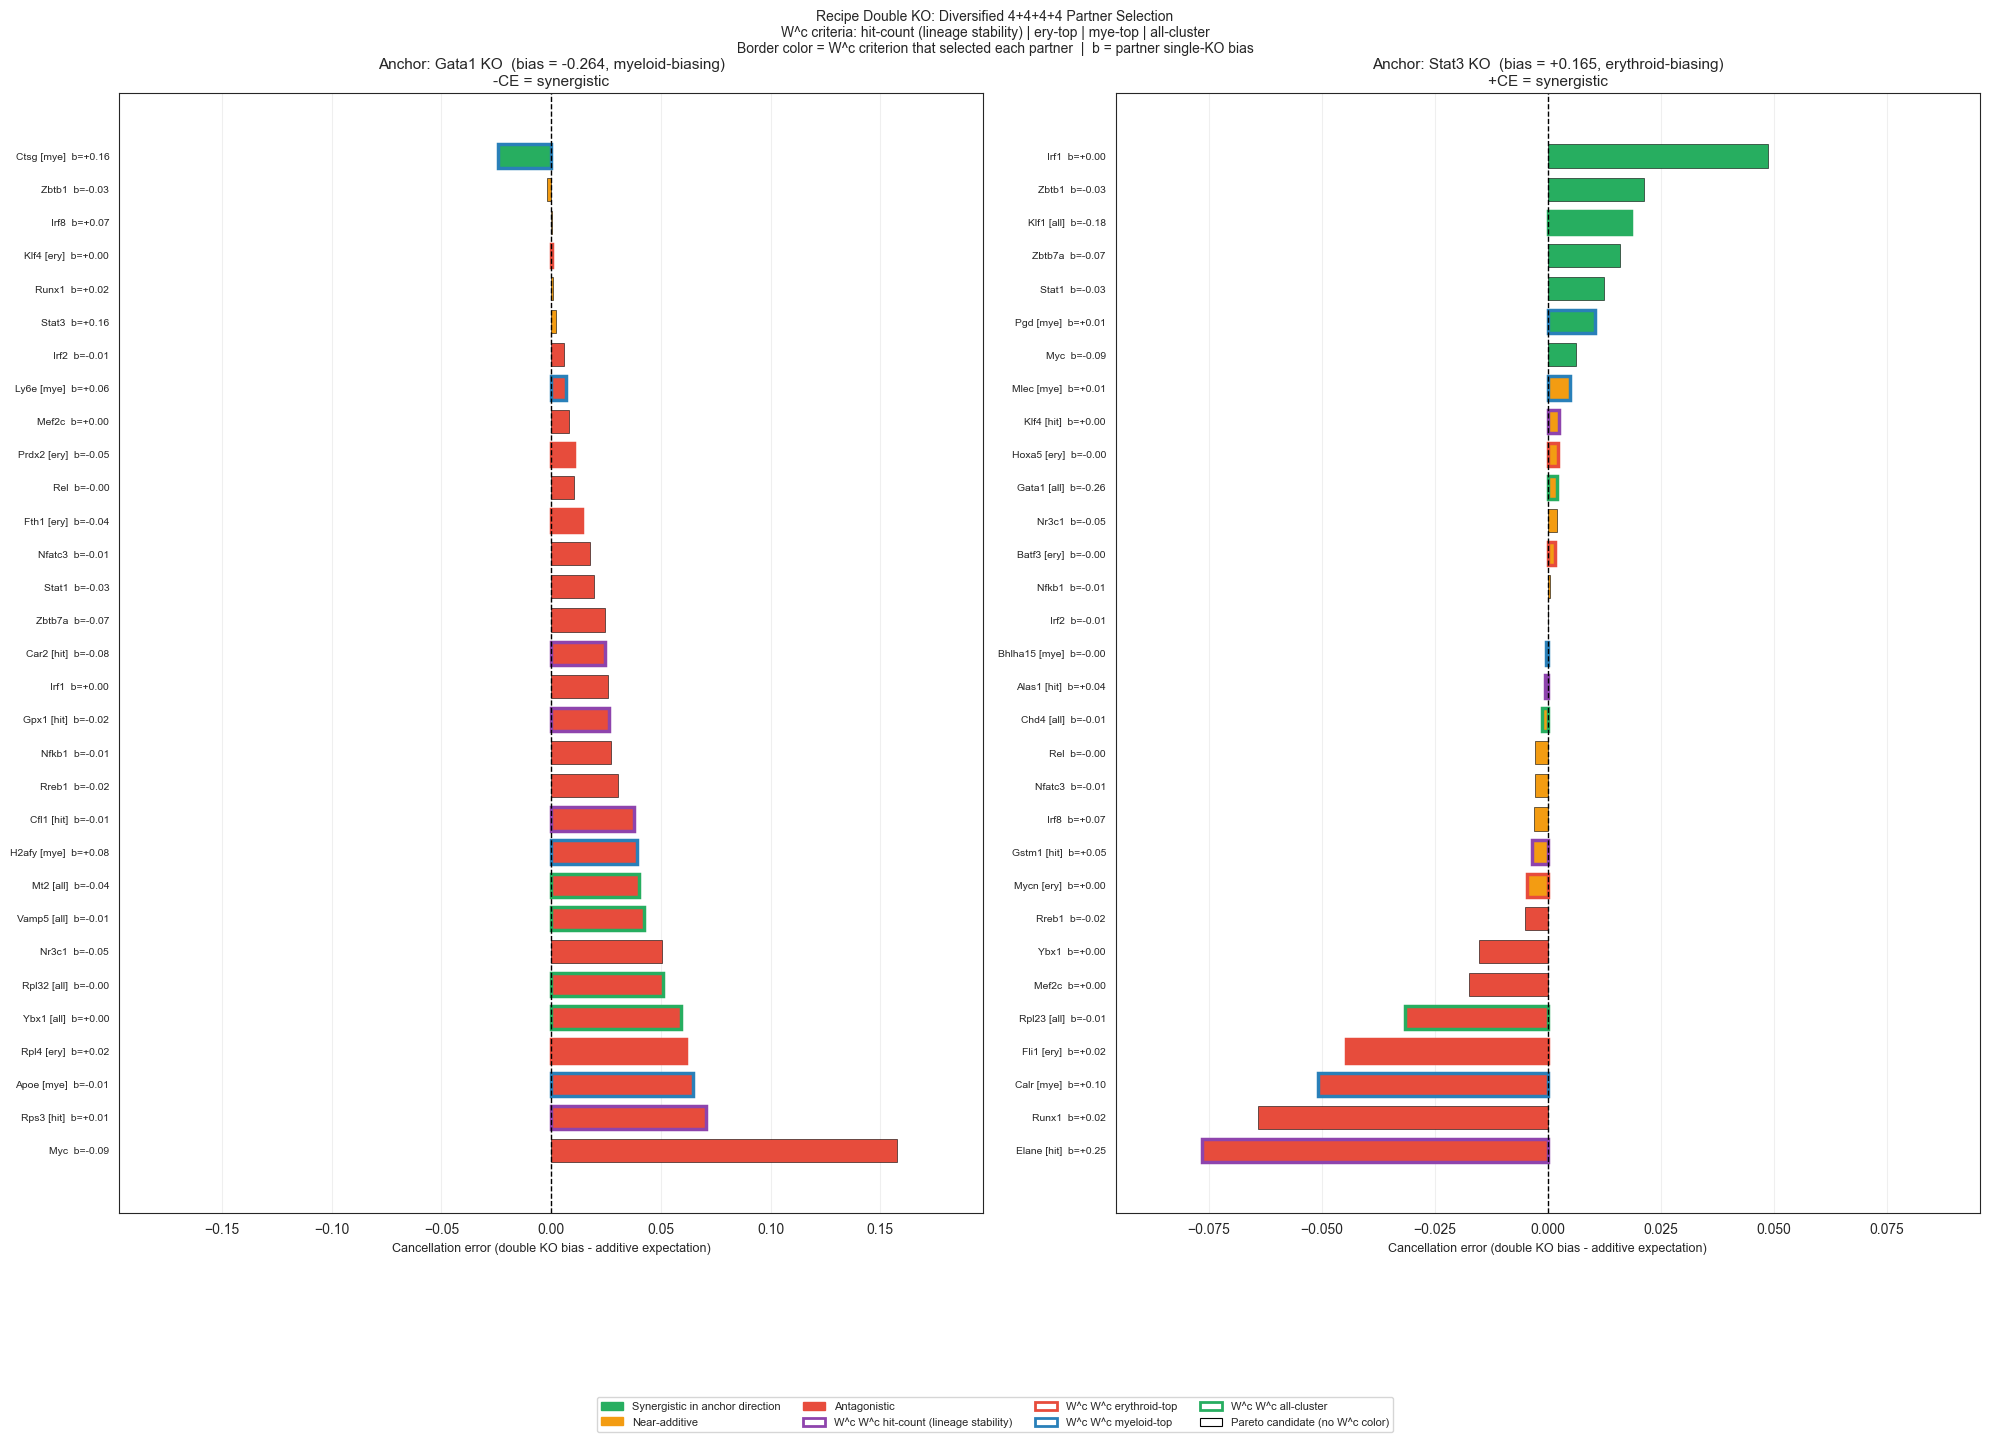

Saved -> /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/recipe_double_ko.png

=== W^c-derived findings by criterion ===

Anchor Gata1 — W^c candidates by criterion:
  hit_count:
    Car2        CE=+0.0246  synergy=-0.0246  bias_partner=-0.077
    Gpx1        CE=+0.0264  synergy=-0.0264  bias_partner=-0.018
    Cfl1        CE=+0.0379  synergy=-0.0379  bias_partner=-0.013
    Rps3        CE=+0.0707  synergy=-0.0707  bias_partner=+0.010
  ery_top:
    Klf4        CE=+0.0005  synergy=-0.0005  bias_partner=+0.002
    Prdx2       CE=+0.0102  synergy=-0.0102  bias_partner=-0.051
    Fth1        CE=+0.0141  synergy=-0.0141  bias_partner=-0.040
    Rpl4        CE=+0.0617  synergy=-0.0617  bias_partner=+0.018
  mye_top:
    Ctsg        CE=-0.0244  synergy=+0.0244  bias_partner=+0.164
    Ly6e        CE=+0.0066  synergy=-0.0066  bias_partner=+0.058
    H2afy       CE=+0.0390  synergy=-0.0390  bias_partner=+0.082
    Apoe        CE=+0.0648  synergy=-0.0648  bias_partner=-0.010

In [118]:

# ── H3: Recipe double KO plot — 4+4+4+4 diversified pools ─────────────────────────
#
# Criterion color coding on bar edge: each W^c criterion gets a distinct border color.
# Fill: green = synergistic, red = antagonistic, orange = near-additive (|synergy_score| < 0.005).

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

CRIT_COLORS = {
    'hit_count': '#8E44AD',   # purple
    'ery_top':   '#E74C3C',   # red
    'mye_top':   '#2980B9',   # blue
    'all_W':     '#27AE60',   # green
    '':          'none',      # Pareto (no border highlight)
}
CRIT_LABELS = {
    'hit_count': 'W^c hit-count (lineage stability)',
    'ery_top':   'W^c erythroid-top',
    'mye_top':   'W^c myeloid-top',
    'all_W':     'W^c all-cluster',
}

fig, axes = plt.subplots(1, 2, figsize=(20, 14), sharey=False)

for ax_idx, anchor in enumerate(['Gata1', 'Stat3']):
    bias_anchor = single_ko_dict.get(anchor, {}).get('lineage_bias', 0)
    bias_sign   = 1 if bias_anchor > 0 else -1
    anchor_dir  = 'erythroid' if bias_sign > 0 else 'myeloid'

    sub = recipe_df[recipe_df['anchor'] == anchor].copy()
    sub = sub.sort_values('synergy_score', ascending=False).reset_index(drop=True)

    ax = axes[ax_idx]

    # Bar fill color by synergy direction
    fill_colors = []
    for s in sub['synergy_score']:
        if   s >  0.005: fill_colors.append('#27AE60')   # synergistic
        elif s < -0.005: fill_colors.append('#E74C3C')   # antagonistic
        else:             fill_colors.append('#F39C12')  # near-additive

    bars = ax.barh(range(len(sub)), sub['cancellation_error'].values,
                   color=fill_colors, edgecolor='k', linewidth=0.4, height=0.7)

    # Criterion border: thicker colored edge for W^c bars
    for yi, (_, row) in enumerate(sub.iterrows()):
        crit = row['wc_criterion']
        if crit and crit in CRIT_COLORS:
            ax.barh(yi, row['cancellation_error'],
                    color='none', edgecolor=CRIT_COLORS[crit],
                    linewidth=2.5, height=0.7)

    # Y-axis labels
    labels = []
    for _, row in sub.iterrows():
        crit_tag  = f' [{row["wc_criterion"][:3]}]' if row['wc_criterion'] else ''
        bias_tag  = f'  b={row["bias_partner"]:+.2f}'
        labels.append(f"{row['partner']}{crit_tag}{bias_tag}")
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(labels, fontsize=7.5)

    ax.axvline(0, color='k', lw=1, ls='--')

    xlim = max(abs(sub['cancellation_error'].max()),
               abs(sub['cancellation_error'].min())) * 1.25
    ax.set_xlim(-xlim, xlim)

    synergy_dir = '+CE = synergistic' if bias_sign > 0 else '-CE = synergistic'
    ax.set_title(
        f'Anchor: {anchor} KO  (bias = {bias_anchor:+.3f}, {anchor_dir}-biasing)\n'
        f'{synergy_dir}', fontsize=11)
    ax.set_xlabel('Cancellation error (double KO bias - additive expectation)', fontsize=9)
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)

# Legend
legend_elements = [
    mpatches.Patch(color='#27AE60', label='Synergistic in anchor direction'),
    mpatches.Patch(color='#F39C12', label='Near-additive'),
    mpatches.Patch(color='#E74C3C', label='Antagonistic'),
]
for crit, color in CRIT_COLORS.items():
    if crit:
        legend_elements.append(
            mpatches.Patch(facecolor='white', edgecolor=color, linewidth=2,
                           label=f'W^c {CRIT_LABELS[crit]}'))
legend_elements.append(
    mpatches.Patch(facecolor='white', edgecolor='k', linewidth=0.8,
                   label='Pareto candidate (no W^c color)'))

fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    'Recipe Double KO: Diversified 4+4+4+4 Partner Selection\n'
    'W^c criteria: hit-count (lineage stability) | ery-top | mye-top | all-cluster\n'
    'Border color = W^c criterion that selected each partner  |  b = partner single-KO bias',
    fontsize=10)

plt.tight_layout(rect=[0, 0.08, 1, 1])
import os
plt.savefig(EXT_SAVE_DIR / 'recipe_double_ko.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved -> {EXT_SAVE_DIR / 'recipe_double_ko.png'}")

# Print W^c findings per criterion
print("\n=== W^c-derived findings by criterion ===")
for anchor in ['Gata1', 'Stat3']:
    bias_anchor = single_ko_dict.get(anchor, {}).get('lineage_bias', 0)
    bias_sign   = 1 if bias_anchor > 0 else -1
    sub = recipe_df[recipe_df['anchor'] == anchor].copy()
    sub['synergy_score'] = sub['cancellation_error'] * bias_sign
    wc_only = sub[sub['is_wc']].sort_values('synergy_score', ascending=False)
    print(f"\nAnchor {anchor} — W^c candidates by criterion:")
    for crit in ['hit_count', 'ery_top', 'mye_top', 'all_W']:
        rows = wc_only[wc_only['wc_criterion'] == crit]
        if not rows.empty:
            print(f"  {crit}:")
            for _, r in rows.iterrows():
                print(f"    {r['partner']:10s}  CE={r['cancellation_error']:+.4f}  "
                      f"synergy={r['synergy_score']:+.4f}  bias_partner={r['bias_partner']:+.3f}")


## Section I: STAT Family Regulatory Circuit via W^c Inspection

**Question:** What regulatory relationships does the inferred GRN encode among the full STAT family (Stat1–Stat6) and known interactors (Irf8, Gata1)? Do these match known biology?

**STAT TFs found in model**: Stat1, Stat3, Stat4, Stat5a, Irf8, Gata1. (Stat2, Stat5b, Stat6 not in the 1999-gene scaffold.)

**Method:** Extract the N×N sub-matrix of mean W^c weights (averaged across all clusters, erythroid clusters, myeloid clusters) for the genes above. Each element W^c[i,j] represents the mean inferred regulatory weight from gene i (regulator) to gene j (target). Positive = activation, negative = repression.

**Key literature facts used for concordance check:**
- **Stat3 auto-activation**: Stat3 has positive auto-feedback via JAK-STAT signaling loops (Darnell 1997; multiple reviews). Expected: W^c[Stat3,Stat3] > 0.
- **Stat1 → Stat3 repression**: Stat1 and Stat3 compete for overlapping DNA binding sites (GAS elements); Stat1 signaling shifts lineage fate away from Stat3-driven myeloid programs. Expected: W^c[Stat1,Stat3] < 0.
- **Stat3 → Irf8 repression**: STAT3 activation constitutively suppresses Irf8 mRNA; STAT3 inhibition causes Irf8 to be the most upregulated TF (Gabrilovich/JCI 2013; Swaminathan/PMC 2014). Expected: W^c[Stat3,Irf8] < 0.
- **Irf8 → Stat3 repression**: Irf8 drives monocyte/DC differentiation and antagonizes MDSC-promoting STAT3 activity. Expected: W^c[Irf8,Stat3] < 0.
- **Stat5a → Gata1 activation**: STAT5-induced erythropoiesis is entirely GATA1-dependent; Stat5 and Gata1 co-regulate erythroid genes (Choudhary/Blood 2010). Expected: W^c[Stat5a,Gata1] > 0.
- **Gata1 → Stat5a**: Gata1 regulates Epo receptor pathway including Stat5 axis (Gutierrez/IUBMB 2020). Expected: W^c[Gata1,Stat5a] > 0.

STAT TFs present in model (6): ['Stat1', 'Stat3', 'Stat4', 'Stat5a', 'Irf8', 'Gata1']

Cluster groups: all=19, ery=7, mye=10


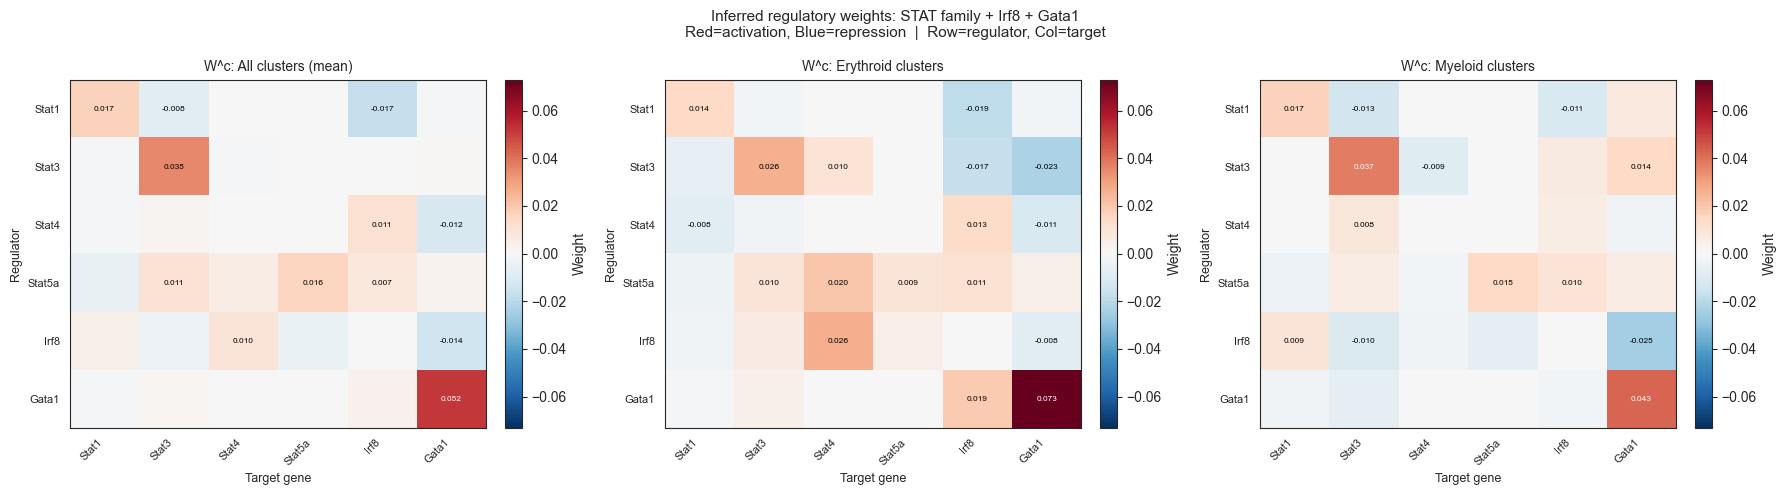

Saved -> /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/stat_circuit_heatmap.png

=== W^c Concordance with Literature ===
  Stat3    -> Stat3     | W=+0.0352 (activation  ) | expected=activation | MATCH  [JAK-STAT auto-feedback]
  Stat1    -> Stat3     | W=-0.0084 (repression  ) | expected=repression | MATCH  [Stat1 competes with Stat3 for DNA binding]
  Stat3    -> Irf8      | W=-0.0004 (near-zero   ) | expected=repression | WEAK/ABSENT  [Stat3 promotes myeloid; Irf8 opposes it]
  Irf8     -> Stat3     | W=-0.0044 (repression  ) | expected=repression | MATCH  [Irf8 represses myeloid-promoting genes]
  Stat5a   -> Gata1     | W=+0.0028 (activation  ) | expected=activation | MATCH  [Stat5 cooperates with Gata1 in erythropoiesis]
  Gata1    -> Stat5a    | W=-0.0000 (near-zero   ) | expected=activation | WEAK/ABSENT  [Gata1 regulates Epo-Stat5 axis]


In [106]:
# ── I: STAT family circuit via W^c ────────────────────────────────────────────
stat_candidates = ['Stat1', 'Stat2', 'Stat3', 'Stat4', 'Stat5a', 'Stat5b', 'Stat6', 'Irf8', 'Gata1']
genes_of_interest = [g for g in stat_candidates if g in adata.var_names]
print(f"STAT TFs present in model ({len(genes_of_interest)}): {genes_of_interest}")

gene_idx_map = {g: list(adata.var_names).index(g) for g in genes_of_interest}
g_indices = [gene_idx_map[g] for g in genes_of_interest]
N = len(genes_of_interest)

# Cluster groupings
ery_clusters = [k for k in varp_keys if any(c in k for c in ['1Ery','2Ery','3Ery','4Ery','5Ery','6Ery','7MEP'])]
mye_clusters = [k for k in varp_keys if any(c in k for c in ['9GMP','10GMP','11DC','12Baso','13Baso','14Mo','15Mo','16Neu','17Neu','18Eos'])]

def extract_submatrix(cluster_keys):
    W_sum = np.zeros((N, N))
    for key in cluster_keys:
        W_c = np.asarray(adata.varp[key])
        sub = W_c[np.ix_(g_indices, g_indices)]
        W_sum += sub
    return W_sum / len(cluster_keys)

W_all = extract_submatrix(varp_keys)
W_ery = extract_submatrix(ery_clusters) if ery_clusters else np.zeros((N, N))
W_mye = extract_submatrix(mye_clusters) if mye_clusters else np.zeros((N, N))

print(f"\nCluster groups: all={len(varp_keys)}, ery={len(ery_clusters)}, mye={len(mye_clusters)}")

# ── Plot: 1x3 heatmap ─────────────────────────────────────────────────────────
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vmax = max(np.abs(W_all).max(), np.abs(W_ery).max(), np.abs(W_mye).max())
vmax = max(vmax, 0.01)   # avoid zero range

for ax, W, title in zip(axes, [W_all, W_ery, W_mye],
                              ['All clusters (mean)', 'Erythroid clusters', 'Myeloid clusters']):
    im = ax.imshow(W, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(N))
    ax.set_xticklabels(genes_of_interest, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(N))
    ax.set_yticklabels(genes_of_interest, fontsize=8)
    ax.set_xlabel('Target gene', fontsize=9)
    ax.set_ylabel('Regulator', fontsize=9)
    ax.set_title(f'W^c: {title}', fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Weight')

    # Annotate non-zero cells
    for i in range(N):
        for j in range(N):
            val = W[i, j]
            if abs(val) > vmax * 0.1:
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=6, color='white' if abs(val) > vmax * 0.5 else 'black')

plt.suptitle('Inferred regulatory weights: STAT family + Irf8 + Gata1\n'
             'Red=activation, Blue=repression  |  Row=regulator, Col=target', fontsize=11)
plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'stat_circuit_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved -> {EXT_SAVE_DIR / 'stat_circuit_heatmap.png'}")

# ── Concordance table (W^c vs literature) ────────────────────────────────────
print("\n=== W^c Concordance with Literature ===")
known_edges = {
    ('Stat3', 'Stat3'): ('activation', 'JAK-STAT auto-feedback'),
    ('Stat1', 'Stat3'): ('repression', 'Stat1 competes with Stat3 for DNA binding'),
    ('Stat3', 'Irf8'):  ('repression', 'Stat3 promotes myeloid; Irf8 opposes it'),
    ('Irf8',  'Stat3'): ('repression', 'Irf8 represses myeloid-promoting genes'),
    ('Stat5a','Gata1'): ('activation', 'Stat5 cooperates with Gata1 in erythropoiesis'),
    ('Gata1', 'Stat5a'):('activation', 'Gata1 regulates Epo-Stat5 axis'),
}

for (reg, tgt), (expected_dir, source) in known_edges.items():
    if reg not in gene_idx_map or tgt not in gene_idx_map:
        print(f"  {reg:8s} -> {tgt:8s}  | MISSING from model")
        continue
    ri = genes_of_interest.index(reg)
    ti = genes_of_interest.index(tgt)
    w_val = W_all[ri, ti]
    model_dir = 'activation' if w_val > 0.001 else ('repression' if w_val < -0.001 else 'near-zero')
    match = 'MATCH' if model_dir == expected_dir else ('NOVEL/DISAGREE' if model_dir != 'near-zero' else 'WEAK/ABSENT')
    print(f"  {reg:8s} -> {tgt:8s}  | W={w_val:+.4f} ({model_dir:12s}) | expected={expected_dir:10s} | {match}  [{source}]")

In [108]:
# ── Step 5: Assemble figures 7, 8, 9 ────────────────────────────────────────
import subprocess, sys, os

scripts = [
    '/Users/bernaljp/Documents/scHopfieldPaper/paper/figures/assemble_abridged_fig7.py',
    '/Users/bernaljp/Documents/scHopfieldPaper/paper/figures/assemble_abridged_fig8.py',
    '/Users/bernaljp/Documents/scHopfieldPaper/paper/figures/assemble_abridged_fig9.py',
]

env = {**os.environ, 'MPLBACKEND': 'Agg'}   # avoid matplotlib_inline interference
for script in scripts:
    result = subprocess.run([sys.executable, script], capture_output=True, text=True, env=env)
    if result.returncode == 0:
        print(result.stdout.strip())
    else:
        print(f"ERROR in {script}:")
        print(result.stderr[-500:])

Saved: /Users/bernaljp/Documents/scHopfieldPaper/paper/figures/figure_abridged7.png


Saved: /Users/bernaljp/Documents/scHopfieldPaper/paper/figures/figure_abridged8.png


Saved: /Users/bernaljp/Documents/scHopfieldPaper/paper/figures/figure_abridged9.png


## Section F: Future Work

The following analyses were identified as important but are deferred due to scope:

### Perturb-seq Correlation (High priority #2)
Compute Spearman rank correlation between scHopfield lineage bias scores and experimentally
measured differentiation shifts (e.g., Dixit et al. 2016, Norman et al. 2019). Requires
downloading and aligning a Perturb-seq dataset with the hematopoiesis system. Deferred to a
separate notebook.

### Regularization Robustness (Medium priority #8)
Show that Stat3's high lineage bias ranking is stable across scaffold regularization strengths
∈ {0.01, 0.1, 1.0}. Requires full model retraining (~30–60 min per strength level, ×3). The
current model used `scaffold_regularization = 0.1`. Deferred to future validation experiments.

---

## Summary of Key Findings

| Analysis | Key Result |
|----------|-----------|
| **A. Stat3 OE** | lineage_bias = −0.013 (myeloid-biasing) vs Stat3 KO +0.165 — confirms **bidirectional** control of the erythroid/myeloid axis |
| **B. Time-resolved** | Gata1 KO and Stat3 KO show distinct gene-cluster cascade patterns evolving over 20–100 ODE steps |
| **C. Phase portraits** | ODE trajectories from 1Ery/2Ery/3Ery cells diverge clearly under Gata1 vs Stat3 perturbations in the Gata1-Stat3 expression plane |
| **D. Dose-response** | Both genes show **threshold-like** switches: Gata1 transitions near 0.44× natural max; Stat3 transitions near 0.22–0.44× |
| **E. Bootstrap** | Static rank-based metric confirms Stat3 is consistently myeloid-correlated; note static and flow-based metrics use opposite sign conventions |

---
## Section A (revised): Stat3 KO Perturbation Flow

Replaces Stat3 OE. KO is the biologically relevant perturbation (consistent with perturb-seq).  
Shows where cells would move in embedding space when Stat3 is knocked out — expected: erythroid-biasing (red = aligned with WT erythroid flow).

In [ ]:
# ── Stat3 KO simulation + alignment (checkpoint protected) ───────────────────
STAT3_KO_IP_NPY    = EXT_SAVE_DIR / 'stat3_ko_inner_product.npy'
STAT3_KO_FLOW_NPY  = EXT_SAVE_DIR / 'stat3_ko_flow_vectors.npy'
STAT3_KO_COORD_NPY = EXT_SAVE_DIR / 'stat3_ko_embedding_coords.npy'
STAT3_KO_GX_NPY    = EXT_SAVE_DIR / 'stat3_ko_grid_gx.npy'
STAT3_KO_GY_NPY    = EXT_SAVE_DIR / 'stat3_ko_grid_gy.npy'
STAT3_KO_GU_NPY    = EXT_SAVE_DIR / 'stat3_ko_grid_gu.npy'
STAT3_KO_GV_NPY    = EXT_SAVE_DIR / 'stat3_ko_grid_gv.npy'

if STAT3_KO_IP_NPY.exists() and STAT3_KO_GX_NPY.exists():
    print("Loading Stat3 KO from checkpoint...")
    ip_ko   = np.load(STAT3_KO_IP_NPY)
    flow_ko = np.load(STAT3_KO_FLOW_NPY)
    coords  = np.load(STAT3_KO_COORD_NPY)
    GX      = np.load(STAT3_KO_GX_NPY)
    GY      = np.load(STAT3_KO_GY_NPY)
    GU      = np.load(STAT3_KO_GU_NPY)
    GV      = np.load(STAT3_KO_GV_NPY)
else:
    print("Running Stat3 KO simulation...")
    adata_stat3_ko = simulate_shift_ode(
        adata.copy(), {'Stat3': 0.0},
        cluster_key=CLUSTER_KEY, dt=5.0, n_steps=100,
        use_cluster_specific_GRN=True, n_jobs=-1, device=DEVICE,
    )
    sch.tl.calculate_flow(
        adata_stat3_ko, source='delta', basis=BASIS, method='celloracle',
        cluster_key=CLUSTER_KEY, store_key=f'perturbation_flow_{BASIS}', verbose=False,
    )
    sch.tl.calculate_inner_product(
        adata_stat3_ko,
        flow_key_1=_WT_VEL_FLOW_KEY,
        flow_key_2=f'perturbation_flow_{BASIS}',
        store_key='ko_vs_wt_inner_product',
    )
    aln     = sch.tl.compute_perturbation_alignment(adata_stat3_ko, basis=BASIS)
    ip_ko   = aln['ip']
    coords  = aln['coords']
    GX, GY  = aln['GX'], aln['GY']
    GU, GV  = aln['GU'], aln['GV']
    flow_ko = adata_stat3_ko.obsm[f'perturbation_flow_{BASIS}']

    np.save(STAT3_KO_IP_NPY,    ip_ko)
    np.save(STAT3_KO_FLOW_NPY,  flow_ko)
    np.save(STAT3_KO_COORD_NPY, coords)
    np.save(STAT3_KO_GX_NPY,    GX)
    np.save(STAT3_KO_GY_NPY,    GY)
    np.save(STAT3_KO_GU_NPY,    GU)
    np.save(STAT3_KO_GV_NPY,    GV)
    print("Saved checkpoints.")

print(f"ip_ko  : {ip_ko.shape},  range [{ip_ko.min():.3f}, {ip_ko.max():.3f}]")
print(f"flow_ko: {flow_ko.shape}")
print(f"coords : {coords.shape}")

In [ ]:
# ── Plot: Stat3 KO perturbation flow ──────────────────────────────────────────
# GX, GY, GU, GV are precomputed by sch.tl.compute_perturbation_alignment in cell above

fig, ax = plt.subplots(1, 1, figsize=(13, 5))

# Background: cells colored by inner product
vabs = np.percentile(np.abs(ip_ko), 97)
sc0 = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=ip_ko, cmap='RdBu_r', vmin=-vabs, vmax=vabs,
    s=6, alpha=0.7, linewidths=0, rasterized=True,
)
cbar = plt.colorbar(sc0, ax=ax, shrink=0.8, pad=0.01)
cbar.set_label('Flow alignment\n(+erythroid / -myeloid)', fontsize=9)

# Grid arrows: normalize for visibility
speed = np.sqrt(np.where(np.isnan(GU), 0, GU)**2 + np.where(np.isnan(GV), 0, GV)**2)
speed_scale = np.nanpercentile(speed[speed > 0], 90) if (speed > 0).any() else 1.0
GU_norm = GU / (speed_scale + 1e-8)
GV_norm = GV / (speed_scale + 1e-8)

ax.quiver(GX, GY, GU_norm, GV_norm,
          alpha=0.6, scale=25, width=0.003,
          headwidth=4, headlength=5, color='k')

ax.set_title('Stat3 KO -- perturbation flow (inner product vs WT erythroid velocity)',
             fontsize=11)
ax.axis('off')

plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'stat3_ko_flow.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved -> {EXT_SAVE_DIR / 'stat3_ko_flow.png'}")

---
## Section B (revised): Short-time Cascade Timing

Runs Gata1 KO and Stat3 KO at log-scale time points (t = 0.1 → 20 ODE units, dt=0.1).  
Shows which clusters respond first — revealing the cascade order initiated by each perturbation.

In [98]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Short-time cascade ODE runs (checkpoint-protected, ~30 min) ───────────────
shorttime_csv = EXT_SAVE_DIR / 'timeseries_linear_cluster.csv' # Updated filename

# Linear scale from ~0 to 100 (using steps of 5 to avoid dt=0)
time_points = [float(t) for t in range(5, 105, 5)] 
n_steps = 100

rerun = True

if shorttime_csv.exists() and not rerun:
    st_df = pd.read_csv(shorttime_csv)
else:
    records = []
    # 1. Get the indices of the genes used in the model
    genes_used_idx = get_genes_used(adata)
    all_gene_names = adata.var_names.values
    
    # 2. Identify the indices of the genes to exclude (Gata1 and Stat3)
    genes_to_exclude = {'Gata1', 'Stat3'}
    model_gene_names = all_gene_names[genes_used_idx]
    
    # Create a mask: True for genes we want to KEEP
    # We apply this same mask to Wild Type so the baseline is comparable!
    exclude_mask = np.array([g not in genes_to_exclude for g in model_gene_names])

    sorted_times = sorted(time_points)
    time_deltas = np.diff([0] + sorted_times)

    # ADDED: Wild Type condition (None)
    conditions = [(None, 'Wild_Type'), ('Gata1', 'Gata1_KO'), ('Stat3', 'Stat3_KO')]

    for gene, label in conditions:
        curr_adata = adata.copy()
        
        # Determine the perturbation dict (Empty for WT)
        pert_dict = {gene: 0.0} if gene is not None else {}
        
        total_dX_model = np.zeros((curr_adata.n_obs, len(genes_used_idx)))
        
        for i, dt_segment in tqdm(enumerate(time_deltas), total=len(time_deltas), desc=f"Simulating {label}"):
            curr_adata = simulate_shift_ode(
                curr_adata, pert_dict,
                cluster_key=CLUSTER_KEY, dt=dt_segment, n_steps=n_steps,
                use_cluster_specific_GRN=True, device=DEVICE,
            )
            
            # 3. Update the delta
            segment_dX = curr_adata.layers['delta_X'][:, genes_used_idx]
            total_dX_model += segment_dX 
            
            # Apply exclusion mask to the data we are about to average
            filtered_dX = total_dX_model[:, exclude_mask]
            
            temp_df = pd.DataFrame({
                'cluster': curr_adata.obs[CLUSTER_KEY].values,
                'val': np.abs(filtered_dX).mean(axis=1)
            })
            
            cluster_means = temp_df.groupby('cluster', observed=True)['val'].mean()

            for cluster, mean_val in cluster_means.items():
                records.append({
                    'perturbation': label,
                    't_total': sorted_times[i],
                    'cluster': cluster,
                    'mean_abs_delta': float(mean_val),
                })

    st_df = pd.DataFrame(records)
    st_df.to_csv(shorttime_csv, index=False)

Simulating Stat3_KO: 100%|████████████████████████████████████████████████████████████████████████████| 20/20 [02:45<00:00,  8.29s/it]


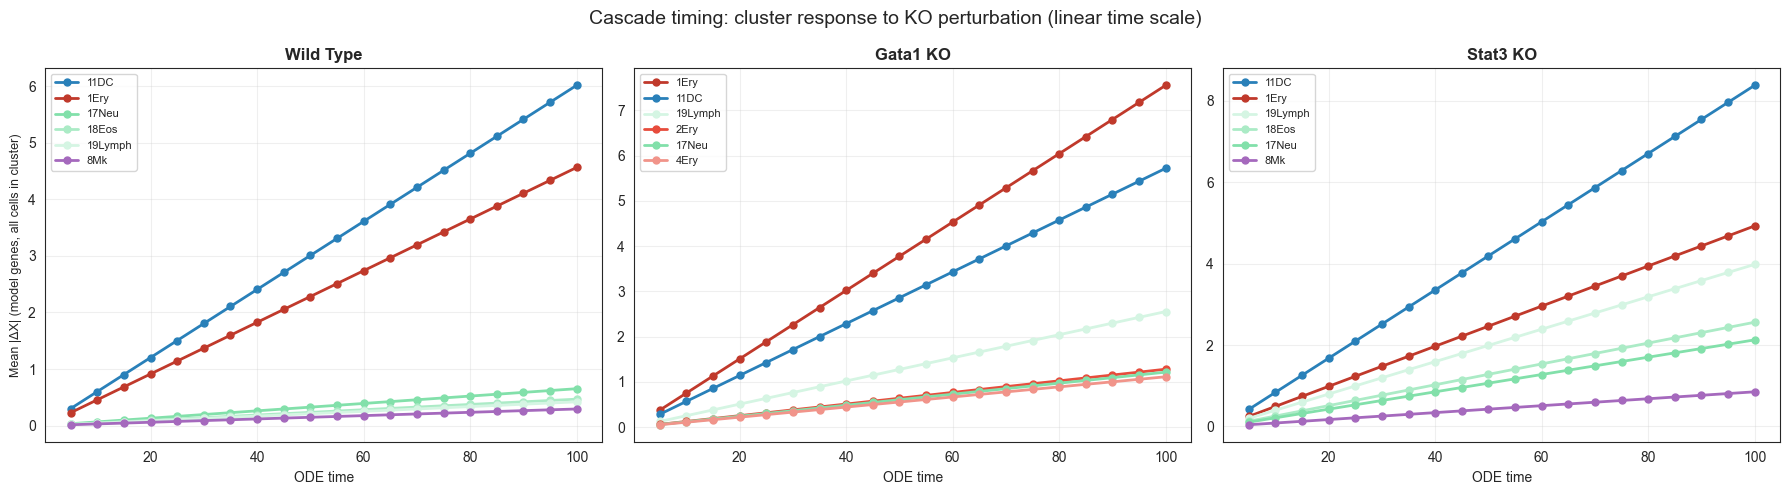

Saved → /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/cascade_timing_linear.png


In [99]:
# ── Plot: Cascade timing — top clusters vs linear time ───────────────────────
cluster_palette = {
    '1Ery': '#C0392B', '2Ery': '#E74C3C', '3Ery': '#EC7063',
    '4Ery': '#F1948A', '5Ery': '#F9B7B0', '6Ery': '#FDDEDE',
    '7MEP': '#884EA0', '8Mk':  '#A569BD',
    '9GMP':  '#1A5276', '10GMP': '#2471A3', '11DC': '#2980B9',
    '12Baso':'#5DADE2', '13Baso':'#85C1E9', '14Mo':  '#27AE60',
    '15Mo':  '#2ECC71', '16Neu': '#52BE80', '17Neu': '#82E0AA',
    '18Eos': '#ABEBC6', '19Lymph':'#D5F5E3',
}

# Expanded to 3 subplots for WT, Gata1, Stat3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cascade timing: cluster response to KO perturbation (linear time scale)', fontsize=14)

plot_conditions = ['Wild_Type', 'Gata1_KO', 'Stat3_KO']

for col, pert in enumerate(plot_conditions):
    sub = st_df[st_df['perturbation'] == pert]
    
    # Top-6 clusters by mean_abs_delta at max time (t=100)
    max_t = sub['t_total'].max()
    top_clusters = (sub[sub['t_total'] == max_t]
                    .sort_values('mean_abs_delta', ascending=False)
                    .head(6)['cluster'].tolist())

    ax = axes[col]
    for cl in top_clusters:
        row = sub[sub['cluster'] == cl].sort_values('t_total')
        color = cluster_palette.get(cl, 'gray')
        # Changed semilogx to standard plot
        ax.plot(row['t_total'], row['mean_abs_delta'],
                'o-', color=color, lw=2, ms=5, label=cl)

    ax.set_xlabel('ODE time', fontsize=10)
    if col == 0:
        ax.set_ylabel('Mean |ΔX| (model genes, all cells in cluster)', fontsize=9)
    
    ax.set_title(pert.replace('_', ' '), fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'cascade_timing_linear.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {EXT_SAVE_DIR / 'cascade_timing_linear.png'}")

---
## Section C (new): TF KO Lineage Bias Ranking

Bar chart of lineage bias for all 16 Pareto-selected candidate TFs from the single KO screen.  
Directly answers: *which TFs are erythroid drivers (positive = KO shifts toward myeloid) vs myeloid drivers (negative = KO shifts toward erythroid)?*

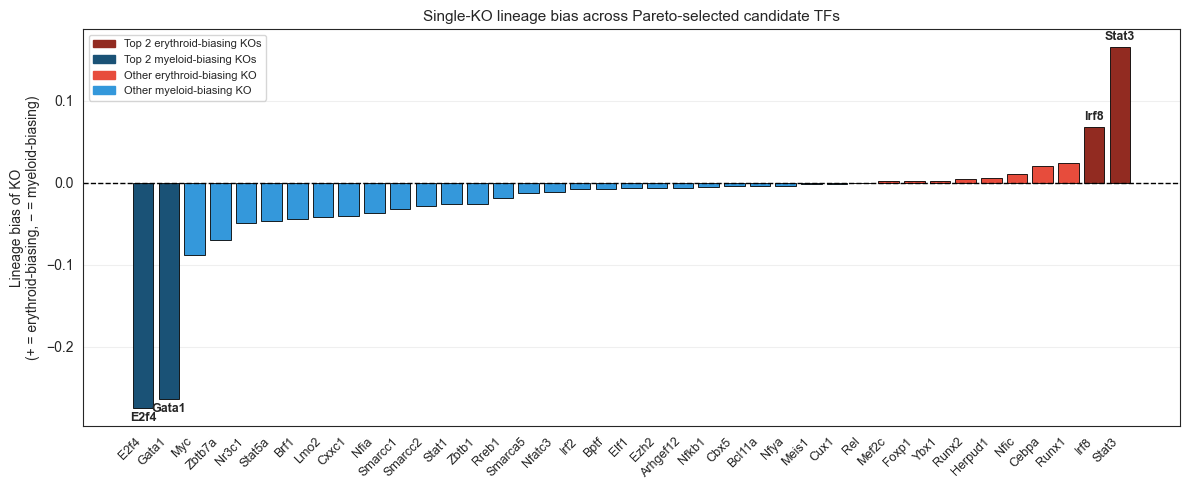

Saved → /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/ko_ranking.png
Top 2 erythroid-biasing KOs:
  - Stat3 (0.1648)
  - Irf8 (0.0676)

Top 2 myeloid-biasing KOs:
  - E2f4 (-0.2743)
  - Gata1 (-0.2637)


In [ ]:
# ── TF KO ranking bar chart ───────────────────────────────────────────────────
df_ko = single_ko_bias[['lineage_bias']].sort_values('lineage_bias').reset_index()
df_ko.columns = ['gene', 'lineage_bias']

# Auto-detect top 2 hits on each side (since it's sorted, head is bottom, tail is top)
top_neg_indices = df_ko.head(2).index.tolist()
top_pos_indices = df_ko.tail(2).index.tolist()

top_neg_genes = df_ko.loc[top_neg_indices, 'gene'].tolist()
top_pos_genes = df_ko.loc[top_pos_indices, 'gene'].tolist()

def bar_color(i, bias):
    if i in top_pos_indices: return '#922B21'  # Dark Red
    if i in top_neg_indices: return '#1A5276'  # Dark Blue
    return '#E74C3C' if bias > 0 else '#3498DB'

colors = [bar_color(i, v) for i, v in zip(df_ko.index, df_ko['lineage_bias'])]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(df_ko)), df_ko['lineage_bias'],
       color=colors, edgecolor='k', linewidth=0.6)
ax.axhline(0, color='k', lw=1, ls='--')

# Label the top 2 on both sides
for i, row in df_ko.iterrows():
    if i in top_pos_indices or i in top_neg_indices:
        ax.text(i, row['lineage_bias'] + 0.005 * np.sign(row['lineage_bias']),
                row['gene'], ha='center',
                va='bottom' if row['lineage_bias'] > 0 else 'top',
                fontsize=9, fontweight='bold')

ax.set_xticks(range(len(df_ko)))
ax.set_xticklabels(df_ko['gene'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Lineage bias of KO\n(+ = erythroid-biasing, − = myeloid-biasing)', fontsize=10)
ax.set_title('Single-KO lineage bias across Pareto-selected candidate TFs', fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# Updated legend mapping to match the bar_color function correctly
from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#922B21', label='Top 2 erythroid-biasing KOs'),
    Patch(color='#1A5276', label='Top 2 myeloid-biasing KOs'),
    Patch(color='#E74C3C', label='Other erythroid-biasing KO'),
    Patch(color='#3498DB', label='Other myeloid-biasing KO'),
]
ax.legend(handles=legend_handles, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(EXT_SAVE_DIR / 'ko_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statements formatted for multiple genes
print(f"Saved → {EXT_SAVE_DIR / 'ko_ranking.png'}")
print("Top 2 erythroid-biasing KOs:")
for idx, gene in zip(top_pos_indices[::-1], top_pos_genes[::-1]): # Reverse to print highest first
    print(f"  - {gene} ({df_ko.loc[idx, 'lineage_bias']:.4f})")
    
print("\nTop 2 myeloid-biasing KOs:")
for idx, gene in zip(top_neg_indices, top_neg_genes):
    print(f"  - {gene} ({df_ko.loc[idx, 'lineage_bias']:.4f})")

---
## Section D (new): Cluster-level ΔX at Convergence

Shows which clusters are most perturbed by Gata1 KO vs Stat3 KO at ODE convergence (t=500).  
Directly answers: *where in the lineage does each perturbation act?*

Cluster summary at convergence:
cluster           1Ery      2Ery      3Ery      4Ery      5Ery      6Ery      7MEP       8Mk      9GMP     10GMP      11DC    12Baso    13Baso      14Mo      15Mo     16Neu     17Neu     18Eos   19Lymph
perturbation                                                                                                                                                                                              
Gata1_KO      0.377660  0.064562  0.054434  0.056094  0.044744  0.026938  0.020095  0.039025  0.012549  0.010363  0.286095  0.018470  0.009530  0.012869  0.010133  0.010458  0.061029  0.051916  0.128055
Stat3_KO      0.246151  0.009652  0.009543  0.009985  0.009997  0.010808  0.014368  0.042709  0.033182  0.012688  0.419256  0.024301  0.012419  0.018806  0.022313  0.021605  0.106496  0.128148  0.199317


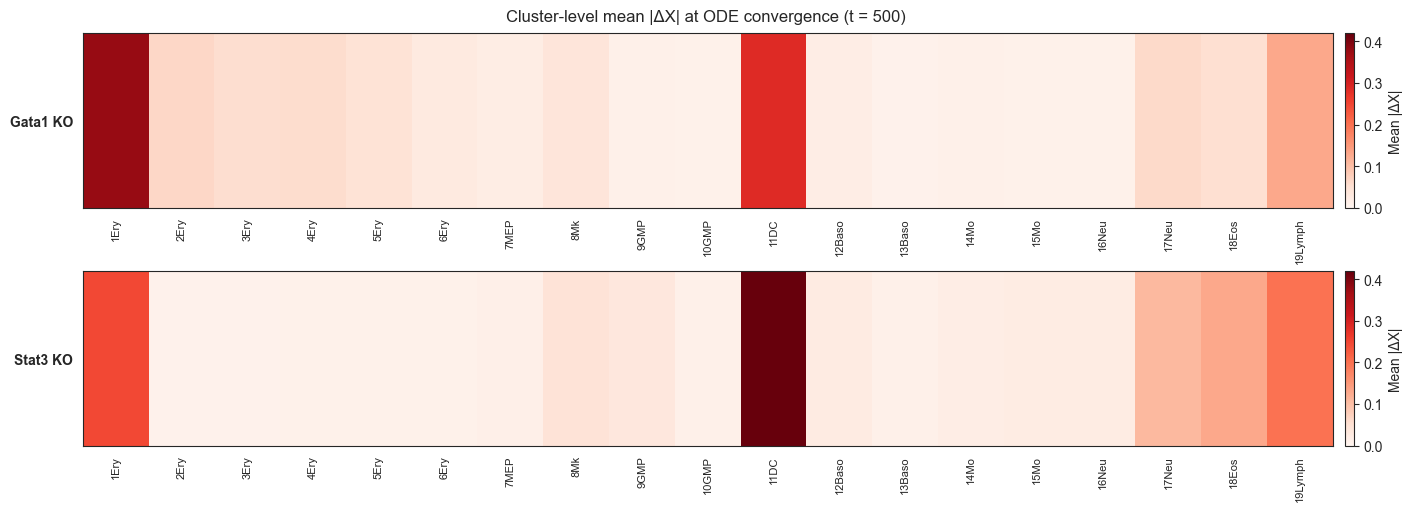

Saved → /Users/bernaljp/Documents/SCHData/checkpoints/perturbation_extended/cluster_effects_heatmap.png


In [66]:
# ── Cluster ΔX heatmap at convergence (from existing timeseries checkpoint) ───
# Use n_steps=100 (t=500) from existing timeseries_cluster_effects.csv
# ts_df already loaded; aggregate mean|ΔX| per (perturbation, cluster) over all genes
ts100 = ts_df[ts_df['n_steps'] == 100]
cluster_summary = (ts100
                   .groupby(['perturbation', 'cluster'])['mean_abs_delta']
                   .mean()
                   .unstack('cluster')
                   .reindex(columns=CLUSTER_ORDER)
                   .fillna(0))

print("Cluster summary at convergence:")
print(cluster_summary.to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 5), constrained_layout=True)
fig.suptitle('Cluster-level mean |ΔX| at ODE convergence (t = 500)',
             fontsize=12)

vmax = cluster_summary.values.max()

for row_idx, pert in enumerate(['Gata1_KO', 'Stat3_KO']):
    ax = axes[row_idx]
    vals = cluster_summary.loc[pert].values.reshape(1, -1)
    im = ax.imshow(vals, aspect='auto', cmap='Reds', vmin=0, vmax=vmax)
    ax.set_xticks(range(len(CLUSTER_ORDER)))
    ax.set_xticklabels(CLUSTER_ORDER, rotation=90, fontsize=8)
    ax.set_yticks([0])
    ax.set_yticklabels([pert.replace('_', ' ')], fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label='Mean |ΔX|')

plt.savefig(EXT_SAVE_DIR / 'cluster_effects_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {EXT_SAVE_DIR / 'cluster_effects_heatmap.png'}")

---
## Figure Assembly

Compose final multi-panel figures using figurelib and copy to paper figures folder.

In [52]:
# ── Assemble composed figures ─────────────────────────────────────────────────
import sys
sys.path.insert(0, '/Users/bernaljp/Documents/scHopfieldPaper/.claude/skills/figure-editor/lib')
from figurelib import Panel
import figurelib

PAPER_FIGS = Path('/Users/bernaljp/Documents/scHopfieldPaper/paper/figures')

# Figure 5: Stat3 KO flow (A) + Dose-response (B)
figurelib.assemble(
    panels=[
        Panel(image=str(EXT_SAVE_DIR / 'stat3_ko_flow.png'),  label='A'),
        Panel(image=str(EXT_SAVE_DIR / 'dose_response.png'),  label='B'),
    ],
    layout='1+1',
    output=str(PAPER_FIGS / 'figure_abridged5.png'),
    dpi=300,
)
print("figure_abridged5.png assembled")

# Figure 6: Cascade timing (A) + TF ranking (B) + Cluster heatmap (C)
figurelib.assemble(
    panels=[
        Panel(image=str(EXT_SAVE_DIR / 'cascade_timing.png'),         label='A'),
        Panel(image=str(EXT_SAVE_DIR / 'ko_ranking.png'),             label='B'),
        Panel(image=str(EXT_SAVE_DIR / 'cluster_effects_heatmap.png'),label='C'),
    ],
    layout='1+2',
    output=str(PAPER_FIGS / 'figure_abridged6.png'),
    dpi=300,
)
print("figure_abridged6.png assembled")
print(f"\nFigures saved to: {PAPER_FIGS}")

figure_abridged5.png assembled


figure_abridged6.png assembled

Figures saved to: /Users/bernaljp/Documents/scHopfieldPaper/paper/figures
